# CALIMA — Dust and PAH Processes Deep Dive

This notebook focuses on the **physical processes** that drive dust and PAH evolution in CALIMA.
It uses a single silicate grain bin (**DustBin_03**) and a single PAH family (**PAHbin_01**) as concrete examples.

Topics covered:

1. **Imports and setup**
2. **Anatomy of a dust bin in the JSON** — every field in DustBin_03 explained
3. **Anatomy of a PAH bin in the JSON** — every field in PAHbin_01 explained
4. **The physics flag block** — mapping JSON flags → rate modules
5. **The models block** — choosing variants for coagulation, shattering, photolysis, etc.
6. **Inspecting rate tables loaded at runtime** — sputtering yields, photolysis table
7. **Running isolated processes** — accretion, sputtering, coagulation, PAH photolysis
8. **Export functions** — `save_chemistry_txt`, `save_equilibrium_txt`, and reading them back
9. **Visualising the results** — time-series and bar-chart comparisons


---
## 1. Imports and Setup


In [1]:
import json
import copy
import tempfile
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# CALIMA solver modules
from solvers.run_chemistry import run_chemistry, compute_element_totals
from solvers.dust_init import load_initial_conditions, SEC2MYR
from solvers.rhs import build_process_list, compute_rhs
from solvers.plotting import plot_chemistry_evolution
from solvers.output_writer import save_chemistry_txt, save_equilibrium_txt

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

REPO = Path(".").resolve()
CFG_PATH = REPO / "solvers" / "configs" / "example_ic.json"

with CFG_PATH.open() as fh:
    BASE_CFG = json.load(fh)

print(f"Loaded config: {CFG_PATH.name}")
print(f"  Dust bins : {[b['id'] for b in BASE_CFG['dust_bins']]}")
print(f"  PAH bins  : {[b['id'] for b in BASE_CFG['pah_bins']]}")


Loaded config: example_ic.json
  Dust bins : ['DustBin_01', 'DustBin_02', 'DustBin_03', 'DustBin_04']
  PAH bins  : ['PAHbin_01', 'PAHbin_02']


---
## 2. Anatomy of a Dust Bin — DustBin_03 (small silicate, 0.005 µm)

DustBin_03 is the **small silicate** grain family. Every field is shown below with its meaning.


In [2]:
db3 = next(b for b in BASE_CFG["dust_bins"] if b["id"] == "DustBin_03")
print(json.dumps(db3, indent=2))


{
  "id": "DustBin_03",
  "composition": "silicate",
  "grain_size_micron": 0.005,
  "grain_density_gcm3": 3.3,
  "elements": [
    {
      "name": "Mg",
      "mass_fraction": 0.142
    },
    {
      "name": "Si",
      "mass_fraction": 0.163
    },
    {
      "name": "O",
      "mass_fraction": 0.574
    },
    {
      "name": "Fe",
      "mass_fraction": 0.121
    }
  ],
  "initial_mass_density_gcm3": 6e-28,
  "sticking_coefficient": 1.0,
  "nhmax_acc": 10000.0,
  "nh_coa": 0.1,
  "coagulation_partner": "DustBin_04",
  "amin_micron": 0.002,
  "amax_micron": 0.015,
  "catastrophic_specific_energy_erg_g": 10000000.0,
  "interact_pah": false,
  "vthresh_coag_cm_s": 10000.0
}


### Field-by-field explanation

| Field | Value | Meaning |
|---|---|---|
| `id` | `"DustBin_03"` | Unique label; used in output columns and to identify the coagulation partner |
| `composition` | `"silicate"` | Selects sputtering yield tables and composition group for shattering |
| `grain_size_micron` | `0.005` | Characteristic grain radius $a$ [µm]; sets the geometric cross-section and stopping time |
| `grain_density_gcm3` | `3.3` | Bulk grain density $\rho_s$ [g cm⁻³]; enters the grain mass $m = \tfrac{4}{3}\pi a^3 \rho_s$ |
| `elements` | Mg/Si/O/Fe | Elemental mass fractions locked in this bin; determines which gas-phase reservoirs are depleted/returned during accretion/sputtering |
| `initial_mass_density_gcm3` | `6e-28` | Initial dust mass density $\rho_d(t=0)$ [g cm⁻³]; the starting condition for the ODE |
| `sticking_coefficient` | `1.0` | Probability that a gas-phase metal atom sticks on impact (accretion efficiency) |
| `nhmax_acc` | `1e4` | Maximum $n_H$ [cm⁻³] at which accretion is active; suppressed at higher densities |
| `nh_coa` | `0.1` | Minimum $n_H$ [cm⁻³] for coagulation; prevents grain sticking in very diffuse gas |
| `coagulation_partner` | `"DustBin_04"` | The larger bin that receives mass when this small bin coagulates; must be same composition |
| `amin_micron` | `0.002` | Minimum grain size [µm] for the fragment power-law distribution (shattering) |
| `amax_micron` | `0.015` | Maximum grain size [µm] for the fragment distribution |
| `catastrophic_specific_energy_erg_g` | `1e7` | Catastrophic disruption threshold $Q^*$ [erg g⁻¹]; threshold specific energy for shattering |
| `interact_pah` | `false` | Whether fragments from this bin can populate PAH bins; `false` for silicates |
| `vthresh_coag_cm_s` | `1e4` | Maximum relative velocity [cm s⁻¹] for coagulation to occur (sticking window) |


In [3]:
# Derived grain properties computed by load_initial_conditions
state, y_gas_0, y_dust_0 = load_initial_conditions(CFG_PATH)

db3_params = next(db for db in state.dust_bins if db.bin_id == "DustBin_03")

print("DustBin_03 derived quantities (set by load_initial_conditions):")
print(f"  bin_index          = {db3_params.bin_index}   (position in the dust array, PAHs first)")
print(f"  asize_micron       = {db3_params.asize_micron:.4f} µm")
print(f"  asize_cm           = {db3_params.asize_cm:.4e} cm")
print(f"  mgrain             = {db3_params.mgrain:.4e} g  (mass of one grain)")
print(f"  sgrain             = {db3_params.sgrain:.2f} g/cm3 (bulk density)")
print(f"  el_names           = {db3_params.el_names}")
print(f"  el_indices         = {db3_params.el_indices}")
print(f"  el_mfractions      = {db3_params.el_mfractions}")
print(f"  k0_acc             = {db3_params.k0_acc:.4e} cm3/s  (accretion rate constant)")
print(f"  coag_partner_index = {db3_params.coag_partner_index}")
print(f"  nhmax_acc          = {db3_params.nhmax_acc:.0e} cm-3")
print(f"  interact_pah       = {db3_params.interact_pah}")
print(f"  sputtering_interps = {list(db3_params.sputtering_interps.keys())}")


DustBin_03 derived quantities (set by load_initial_conditions):
  bin_index          = 2   (position in the dust array, PAHs first)
  asize_micron       = 0.0050 µm
  asize_cm           = 5.0000e-07 cm
  mgrain             = 1.7279e-18 g  (mass of one grain)
  sgrain             = 3.30 g/cm3 (bulk density)
  el_names           = ['Mg', 'Si', 'O', 'Fe']
  el_indices         = [5, 6, 4, 8]
  el_mfractions      = [0.142, 0.163, 0.574, 0.121]
  k0_acc             = 8.5229e-03 cm3/s  (accretion rate constant)
  coag_partner_index = 3
  nhmax_acc          = 1e+04 cm-3
  interact_pah       = False
  sputtering_interps = ['H', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'Si', 'S', 'Fe']


---
## 3. Anatomy of a PAH Bin — PAHbin_01 (small monomer, $N_C = 54$)

PAHbin_01 represents the **small monomer** PAH family centred on coronene ($N_C = 54$).


In [4]:
pb1_json = next(b for b in BASE_CFG["pah_bins"] if b["id"] == "PAHbin_01")
print(json.dumps(pb1_json, indent=2))


{
  "id": "PAHbin_01",
  "nc": 54,
  "nc_min": 24,
  "nc_max": 96,
  "grain_density_gcm3": 2.24,
  "fpah": 0.1,
  "is_cluster": false,
  "dust_index_interact": 0,
  "nd_bins_interact": 2,
  "initial_mass_density_gcm3": 1e-29
}


### Field-by-field explanation

| Field | Value | Meaning |
|---|---|---|
| `id` | `"PAHbin_01"` | Unique label; appears in output column headers |
| `nc` | `54` | Characteristic number of carbon atoms (coronene); sets the representative PAH mass $m_{\rm PAH} = 12.011 \times N_C$ u |
| `nc_min` | `24` | Lower edge of the bin size distribution (circumcoronene lower bound) |
| `nc_max` | `96` | Upper edge; defines the width of this PAH family |
| `grain_density_gcm3` | `2.24` | Effective bulk density used for geometric cross-sections |
| `fpah` | `0.1` | Fraction of the total carbon budget initially locked in PAHs (used to infer $\rho_{\rm PAH}$ if `initial_mass_density_gcm3` is not set) |
| `is_cluster` | `false` | `true` → this family is a PAH cluster; enables cluster-specific evaporation and coalescence rates |
| `dust_index_interact` | `0` | First dust bin index that this PAH family can freeze onto (PAH freezing process) |
| `nd_bins_interact` | `2` | Number of consecutive dust bins (starting at `dust_index_interact`) this PAH can interact with |
| `initial_mass_density_gcm3` | `1e-29` | Explicit initial $\rho_{\rm PAH}(t=0)$ [g cm⁻³]; overrides the `fpah` estimate |


In [5]:
# Derived PAH properties set by load_initial_conditions
pb1_params = next(pb for pb in state.pah_bins if pb.bin_id == "PAHbin_01")

print("PAHbin_01 derived quantities:")
print(f"  bin_index          = {pb1_params.bin_index}  (position in y_dust; PAHs come before dust bins)")
print(f"  nc                 = {pb1_params.nc}  carbon atoms (characteristic)")
print(f"  nc_min / nc_max    = {pb1_params.nc_min} / {pb1_params.nc_max}")
print(f"  mpah               = {pb1_params.mpah:.4e} g  (mass of characteristic PAH molecule)")
print(f"  apah_cm            = {pb1_params.apah_cm:.4e} cm  (effective radius)")
print(f"  spah               = {pb1_params.spah:.2f} g/cm3  (effective density)")
print(f"  fpah               = {pb1_params.fpah}")
print(f"  is_cluster         = {pb1_params.is_cluster}")
print(f"  dust_index_interact= {pb1_params.dust_index_interact}")
print(f"  nd_bins            = {pb1_params.nd_bins}")
print(f"  dissociation_interp keys = {list(pb1_params.dissociation_interp.keys()) if hasattr(pb1_params.dissociation_interp,'keys') else type(pb1_params.dissociation_interp)}")
print(f"  sputtering_interps keys  = {list(pb1_params.sputtering_interps.keys())}")


PAHbin_01 derived quantities:
  bin_index          = 0  (position in y_dust; PAHs come before dust bins)
  nc                 = 54  carbon atoms (characteristic)
  nc_min / nc_max    = 24 / 96
  mpah               = 1.0770e-21 g  (mass of characteristic PAH molecule)
  apah_cm            = 4.8599e-08 cm  (effective radius)
  spah               = 2.24 g/cm3  (effective density)
  fpah               = 0.1
  is_cluster         = False
  dust_index_interact= 0
  nd_bins            = 2
  dissociation_interp keys = <class 'function'>
  sputtering_interps keys  = ['electrons', 'H', 'He', 'C', 'O']


---
## 4. The `physics` Block — Mapping Flags to Rate Modules

Each boolean in `physics` controls a full rate module.  
The table below maps every flag to the underlying function in `solvers/dust_rates.py` and the bins it affects.


| JSON flag | Rate function | Affects | Notes |
|---|---|---|---|
| `dust_accretion` | `accretion_rate` | All dust bins | Gas-phase metals condense; suppressed at $n_H > n_{H,\max}^{\rm acc}$ |
| `dust_sputtering` | `thermal_sputtering_rate` | All dust bins | Thermal ions erode grains; rate loaded from pre-computed T-tables |
| `dust_coagulation` | `coagulation_rate` / `turbulent_coagulation_rate` | Small → large bin pairs | Mass transferred from `bin` to `coagulation_partner`; model chosen in `models` block |
| `dust_shattering` | `turbulent_shattering_rate` / `turbulent_all_shattering_rate` | Large bin fragments | Fragment mass distributed across bins; `interact_pah=true` allows fragments to populate PAH bins |
| `pah_accretion` | `pah_accretion_rate` | All PAH bins | C atoms from gas condense onto PAH molecules; grows $N_C$ |
| `pah_photolysis` | `pah_photolysis_rate` | All PAH bins | UV photons dissociate C$_2$ units; rate from pre-computed G$_0$–$n_H$ table |
| `pah_sputtering` | `pah_sputtering_rate` | All PAH bins | Ion bombardment destroys PAH molecules; T-dependent yield tables |
| `pah_coalescence` | `totton2012_pah_coalescence_rate` / `tielens2021_...` | PAH bin pairs | Two PAHs merge into a larger molecule; increases `nc` effectively |
| `pah_cluster_evaporation` | `pah_cluster_evaporation_rate` | Cluster-flagged PAH bins only | Photo-evaporation of clusters back to monomers (Montillaud 2014) |
| `pah_freezing` | `pah_freezing_rate` | PAH bins + interacting dust bins | PAH accretes onto a dust grain surface; transfers mass from PAH to dust |


In [6]:
import copy, tempfile, os, json

def _write_tmp(cfg):
    """Write cfg dict to a temp JSON file and return the Path."""
    fd, p = tempfile.mkstemp(suffix=".json", prefix="calima_")
    os.close(fd)
    with open(p, "w") as fh:
        json.dump(cfg, fh, indent=2)
    return Path(p)


def show_active_processes(physics_overrides: dict, label: str = ""):
    """Print which processes are active for a given physics override dict."""
    cfg = copy.deepcopy(BASE_CFG)
    cfg["physics"].update(physics_overrides)
    tmp = _write_tmp(cfg)
    s, _, _ = load_initial_conditions(tmp)
    procs = build_process_list(s)
    os.unlink(tmp)
    names = [p.name for p in procs]
    print(f"{label or str(physics_overrides)}")
    for n in names:
        print(f"  + {n}")
    print()
    return names


# Baseline (only dust physics, no PAH)
show_active_processes(
    {k: False for k in BASE_CFG["physics"]},
    "ALL OFF",
)

show_active_processes(
    {"dust_accretion": True, "dust_sputtering": True,
     "dust_coagulation": True, "dust_shattering": True,
     **{k: False for k in BASE_CFG["physics"] if "pah" in k}},
    "Dust only (acc + sput + coag + shatter)",
)

show_active_processes(
    {**{k: False for k in BASE_CFG["physics"] if "dust" in k},
     "pah_accretion": True, "pah_photolysis": True,
     "pah_sputtering": True, "pah_coalescence": True,
     "pah_cluster_evaporation": True, "pah_freezing": True},
    "PAH only (all PAH processes)",
)

show_active_processes(
    {k: True for k in BASE_CFG["physics"]},
    "ALL ON",
)


ALL OFF

Dust only (acc + sput + coag + shatter)
  + accretion
  + sputtering
  + coagulation
  + shattering

PAH only (all PAH processes)
  + pah_accretion
  + pah_photolysis
  + pah_sputtering
  + pah_coalescence
  + pah_cluster_evaporation
  + pah_freezing

ALL ON
  + accretion
  + sputtering
  + coagulation
  + shattering
  + pah_accretion
  + pah_photolysis
  + pah_sputtering
  + pah_coalescence
  + pah_cluster_evaporation
  + pah_freezing



['accretion',
 'sputtering',
 'coagulation',
 'shattering',
 'pah_accretion',
 'pah_photolysis',
 'pah_sputtering',
 'pah_coalescence',
 'pah_cluster_evaporation',
 'pah_freezing']

---
## 5. The `models` Block — Choosing Process Variants

The `models` block selects *which implementation* to use for each process that has multiple variants.


### 5a. Config-selectable variants (`models` block)

The keys below are read at solver initialisation from `cfg["models"]` and stored on
`DustChemistryState`.  Any key that is absent from the JSON falls back to the default shown.

| Key | Allowed values (default in **bold**) | What it selects |
|---|---|---|
| `coagulation_model` | **`"Aoyama2017"`**, `"turbulent"`, `"turbulent_all"` | Rate kernel for grain–grain coagulation. `Aoyama2017` uses a Jeans-boosted analytical form; `turbulent` uses the Ormel & Cuzzi (2007) relative velocity for self-pairs only; `turbulent_all` considers every bin pair |
| `shattering_model` | **`"turbulent"`**, `"turbulent_all"` | Fragment distribution model. `turbulent_all` shatters across every bin combination; `turbulent` does only self-pair shattering |
| `dust_velocity_model` | **`"Ormel2007"`**, `"Hirashita2019"` | Turbulent relative velocity prescription for dust grains (Ormel & Cuzzi 2007 or Hirashita & Kuo 2019); used by coagulation, shattering, and coalescence |
| `coalescence_model` | **`"Totton2012"`**, `"Tielens2021"` | PAH coalescence sticking efficiency. Totton et al. (2012) uses a collision-theory sticking fraction; Tielens (2021) uses a neutral–neutral approximation |
| `photolysis_model` | **`"RM2026"`** | Source of the PAH C₂-loss photolysis rate table; `RM2026` = Rodriguez-Montero et al. (2026) DFT-based tables |
| `pah_sputtering_model` | **`"RM2026"`** | PAH sputtering yield table source |
| `cluster_evaporation_model` | **`"Montillaud2014"`** | PAH cluster photo-evaporation model (Montillaud et al. 2014) |
| `slope_frag_func` | float (**default 0.4333**) | Power-law index $q$ of the shattering fragment mass distribution $\mathrm{d}n/\mathrm{d}m \propto m^{-q}$ |

---

### 5b. Pre-computed-table models (not yet config-selectable)

The processes below are implemented in the `models/` sub-packages and export
pre-computed lookup tables into `model_data/`.  The physical model choice is fixed
**at table-generation time** (see `models/dust_charge/`, `models/PAH_charge/`,
`models/dust_radiation/`, `models/PAH_radiation/`).

| Process | Physical model | Table directory | Variants |
|---|---|---|---|
| **Dust charging** | Weingartner & Draine (2001) charge distribution $P(Z)$ | `model_data/dust_charging_data/` | Fixed (WD01 formalism); per-composition (`graphite`, `silicate`) |
| **Dust photoelectric heating** | Weingartner & Draine (2001) with Mathis ISRF | `model_data/dust_photoelectric_heating_data/` | Radiation field: `"Mathis"` (default); compositions: `graphite`, `silicate` |
| **PAH photoelectric heating** | Berne et al. (2022) or Tielens (2021) electron-attachment | `model_data/PAH_photoelectric_heating_data/` | `attach_model`: **`"Berne"`** or `"Tielens"`; radiation field: `"Mathis"`, `"Draine"`, `"Habing"`, `"O6V"`, `"B0V"`, `"A0"` |
| **Dust & PAH absorption cross sections** | Draine $Q_\mathrm{abs}$ / $Q_\mathrm{sca}$ tables (Mathis 1983 ISRF-averaged) | `model_data/optical_properties/` | Fixed per bin; `C_abs`, `C_sca`, `C_rp` vs wavelength |
| **Dust equilibrium temperature** | Thermal emission balance from $Q_\mathrm{abs}$ tables | `model_data/optical_properties/` | Fixed (equilibrium temperature grids per bin) |


In [8]:
print("Current models block:")
print(json.dumps(BASE_CFG["models"], indent=2))

print("\nCurrent turbulence block:")
print(json.dumps(BASE_CFG.get("turbulence", {}), indent=2))

KM_S  = 1e5         # cm/s  per km/s
PC_CM = 3.0857e18   # cm    per pc

print("\nNote: sigma and dx from 'turbulence' feed directly into")
print("  state.local_sigma  [cm/s] -> relative velocity dispersion")
print("  state.local_dx     [cm]   -> turbulent injection scale")
print(f"  sigma = {state.local_sigma / KM_S:.4f} km/s  "
      f"  dx = {state.local_dx / PC_CM:.4f} pc")


Current models block:
{
  "_comment": "Model selection strings \u2014 choose physics variant for each process",
  "coagulation_model": "Aoyama2017",
  "shattering_model": "turbulent",
  "dust_velocity_model": "Ormel2007",
  "coalescence_model": "Totton2012",
  "photolysis_model": "RM2026",
  "pah_sputtering_model": "RM2026",
  "cluster_evaporation_model": "Montillaud2014",
  "slope_frag_func": 0.4333
}

Current turbulence block:
{
  "_comment": "Turbulent environment for velocity-dependent processes",
  "local_sigma_km_s": 0.567,
  "local_dx_pc": 10.0
}

Note: sigma and dx from 'turbulence' feed directly into
  state.local_sigma  [cm/s] -> relative velocity dispersion
  state.local_dx     [cm]   -> turbulent injection scale
  sigma = 0.5670 km/s    dx = 9.9999 pc


---
## 6. Inspecting Rate Tables Loaded at Runtime

When `load_initial_conditions` builds each `DustBinParams` and `PAHBinParams`, it reads
pre-computed interpolation tables from `model_data/`.  
This section shows how to interrogate and visualise those tables directly.


DustBin_03 sputtering ion species: ['H', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'Si', 'S', 'Fe']


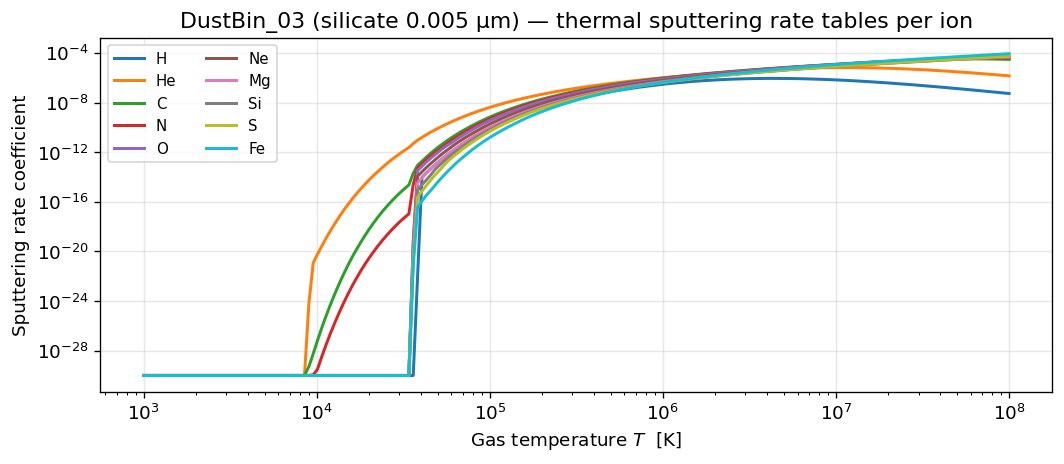

In [9]:
## --- 6a. Dust sputtering yield table (DustBin_03, silicate) ---
# sputtering_interps is a dict keyed by ion species
sput_keys = list(db3_params.sputtering_interps.keys())
print(f"DustBin_03 sputtering ion species: {sput_keys}")

T_probe = np.logspace(3, 8, 200)  # 1e3 to 1e8 K

fig, ax = plt.subplots(figsize=(9, 4))
for key in sput_keys:
    interp = db3_params.sputtering_interps[key]
    # Each interpolator maps T [K] -> erosion rate [cm^2 / s] or similar; evaluate over T range
    try:
        y = interp(T_probe)
        ax.loglog(T_probe, np.maximum(y, 1e-50), label=key, lw=1.8)
    except Exception as err:
        print(f"  Could not evaluate interp for {key}: {err}")

ax.set_xlabel("Gas temperature $T$  [K]")
ax.set_ylabel("Sputtering rate coefficient")
ax.set_title("DustBin_03 (silicate 0.005 µm) — thermal sputtering rate tables per ion")
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
plt.show()


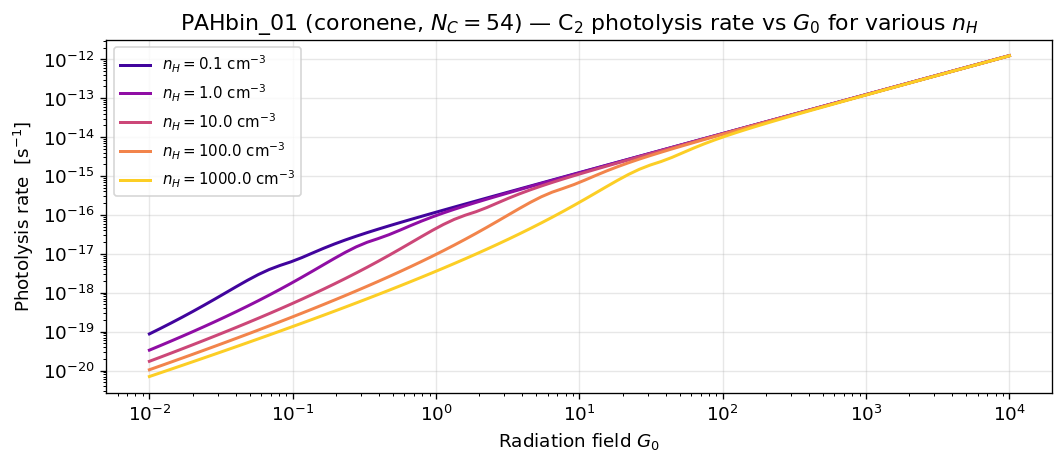

In [11]:
## --- 6b. PAH photolysis rate table (PAHbin_01) ---
# dissociation_interp maps (log10_G0, log10_nH) -> log10(rate [s-1])
G0_probe  = np.logspace(-2, 4, 80)
nH_probes = [0.1, 1.0, 10.0, 100.0, 1000.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(nH_probes)))

fig, ax = plt.subplots(figsize=(9, 4))
diss = pb1_params.dissociation_interp

for nH_val, c in zip(nH_probes, colors):
    rates = []
    for G0_val in G0_probe:
        try:
            log_r = float(diss(np.log10(G0_val), np.log10(nH_val)))
            r = 10.0 ** log_r
        except Exception:
            r = np.nan
        rates.append(r)
    rates = np.array(rates)
    ax.loglog(G0_probe, np.maximum(rates, 1e-50),
              label=rf"$n_H={nH_val}$ cm$^{{-3}}$", color=c, lw=1.8)

ax.set_xlabel(r"Radiation field $G_0$")
ax.set_ylabel(r"Photolysis rate  [s$^{-1}$]")
ax.set_title("PAHbin_01 (coronene, $N_C=54$) — C$_2$ photolysis rate vs $G_0$ for various $n_H$")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


PAHbin_01 sputtering ion species: ['electrons', 'H', 'He', 'C', 'O']


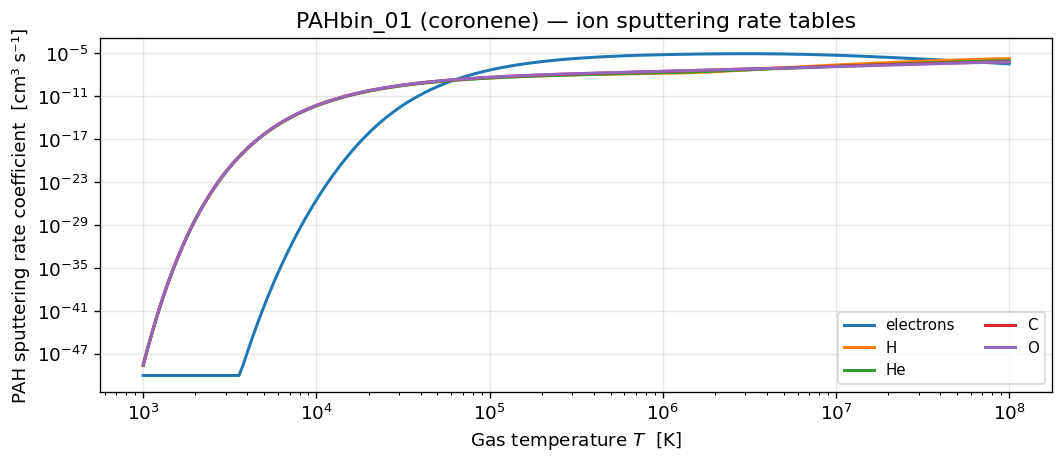

In [13]:
## --- 6c. PAH sputtering table ---
pah_sput_keys = list(pb1_params.sputtering_interps.keys())
print(f"PAHbin_01 sputtering ion species: {pah_sput_keys}")

fig, ax = plt.subplots(figsize=(9, 4))
for key in pah_sput_keys:
    interp = pb1_params.sputtering_interps[key]
    rates = []
    for T_val in T_probe:
        try:
            r = float(interp(float(T_val)))
        except Exception:
            r = np.nan
        rates.append(r)
    rates = np.array(rates)
    ax.loglog(T_probe, np.maximum(rates, 1e-50), label=key, lw=1.8)

ax.set_xlabel("Gas temperature $T$  [K]")
ax.set_ylabel("PAH sputtering rate coefficient  [cm³ s⁻¹]")
ax.set_title("PAHbin_01 (coronene) — ion sputtering rate tables")
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
plt.show()


---
### 6d. Dust grain charging — DustBin_03 (silicate, 0.005 µm)

Pre-computed charge scan from `model_data/dust_charging_data/charge_DustBin_03.json`.  
Each point is one equilibrium charge distribution evaluated at a particular $(G_0, T, n_e)$
combination that all share the same value of the charging parameter
$\gamma = G_0 \sqrt{T} / n_e$.  
The Weingartner & Draine (2001) formalism is used throughout.


Loaded 10000 charge scan points
  bin        : DustBin_03  (silicate, a = 0.005 µm)
  γ range    : 1.0e-06 – 1.0e+06
  T range    : 10 – 100000 K
  ne range   : 3.16e-06 – 3.16e+08 cm⁻³


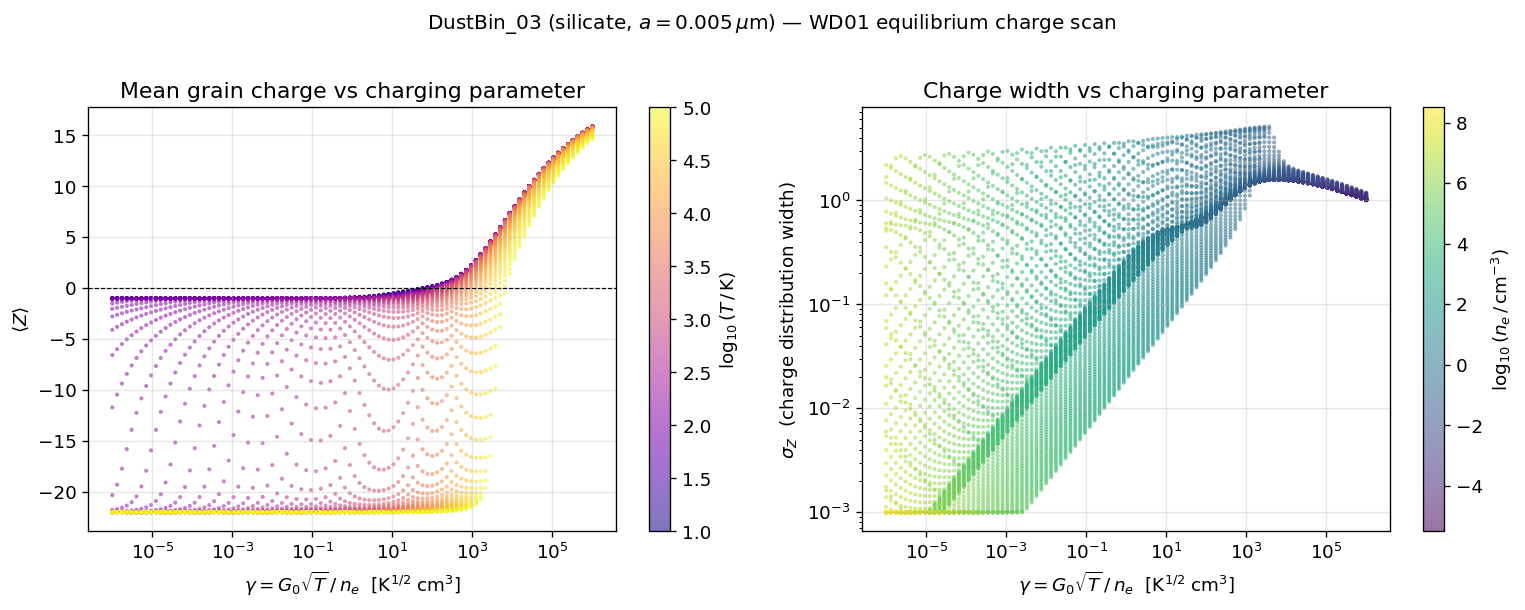

In [15]:
## --- 6d. Dust grain charging scan (DustBin_03, silicate 0.005 µm) ---
# Load the precomputed charge-scan JSON produced by models/dust_charge/
charge_json = REPO / "model_data" / "dust_charging_data" / "charge_DustBin_03.json"
with charge_json.open() as fh:
    charge_data = json.load(fh)

results = charge_data["results"]
gamma_arr  = np.array([r["gamma"]  for r in results])
Zmean_arr  = np.array([r["Zmean"]  for r in results])
Zsigma_arr = np.array([r["Zsigma"] for r in results])
T_arr      = np.array([r["T"]      for r in results])
ne_arr     = np.array([r["ne"]     for r in results])
G0_arr     = np.array([r["G0"]     for r in results])

print(f"Loaded {len(results)} charge scan points")
print(f"  bin        : {charge_data['bin_id']}  ({charge_data['grain_type']}, "
      f"a = {charge_data['grain_size_micron']} µm)")
print(f"  γ range    : {charge_data['gamma_min']:.1e} – {charge_data['gamma_max']:.1e}")
print(f"  T range    : {T_arr.min():.0f} – {T_arr.max():.0f} K")
print(f"  ne range   : {ne_arr.min():.2e} – {ne_arr.max():.2e} cm⁻³")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Zmean vs gamma, coloured by log10(T)
ax = axes[0]
sc = ax.scatter(gamma_arr, Zmean_arr,
                c=np.log10(T_arr), cmap="plasma",
                s=6, alpha=0.55, linewidths=0)
ax.set_xscale("log")
ax.axhline(0, color="k", lw=0.7, ls="--")
ax.set_xlabel(r"$\gamma = G_0 \sqrt{T}\,/\,n_e$  [K$^{1/2}$ cm$^3$]")
ax.set_ylabel(r"$\langle Z \rangle$")
ax.set_title("Mean grain charge vs charging parameter")
plt.colorbar(sc, ax=ax, label=r"$\log_{10}(T\,/\,\mathrm{K})$")

# Right: charge width Zsigma vs gamma, coloured by log10(ne)
ax = axes[1]
sc2 = ax.scatter(gamma_arr, np.maximum(Zsigma_arr, 1e-3),
                 c=np.log10(ne_arr), cmap="viridis",
                 s=6, alpha=0.55, linewidths=0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\gamma = G_0 \sqrt{T}\,/\,n_e$  [K$^{1/2}$ cm$^3$]")
ax.set_ylabel(r"$\sigma_Z$  (charge distribution width)")
ax.set_title("Charge width vs charging parameter")
plt.colorbar(sc2, ax=ax, label=r"$\log_{10}(n_e\,/\,\mathrm{cm}^{-3})$")

fig.suptitle(r"DustBin_03 (silicate, $a=0.005\,\mu$m) — WD01 equilibrium charge scan",
             fontsize=12, y=1.01)
fig.tight_layout()
plt.show()


Dust PEH table: DustBin_03  (silicate, a=0.005 µm)
  T grid     : 10 – 100000 K  (100 points)
  γ grid     : 1.0e-06 – 1.0e+06  (100 points)
  mode       : fix_G0,  G₀ = 1.0


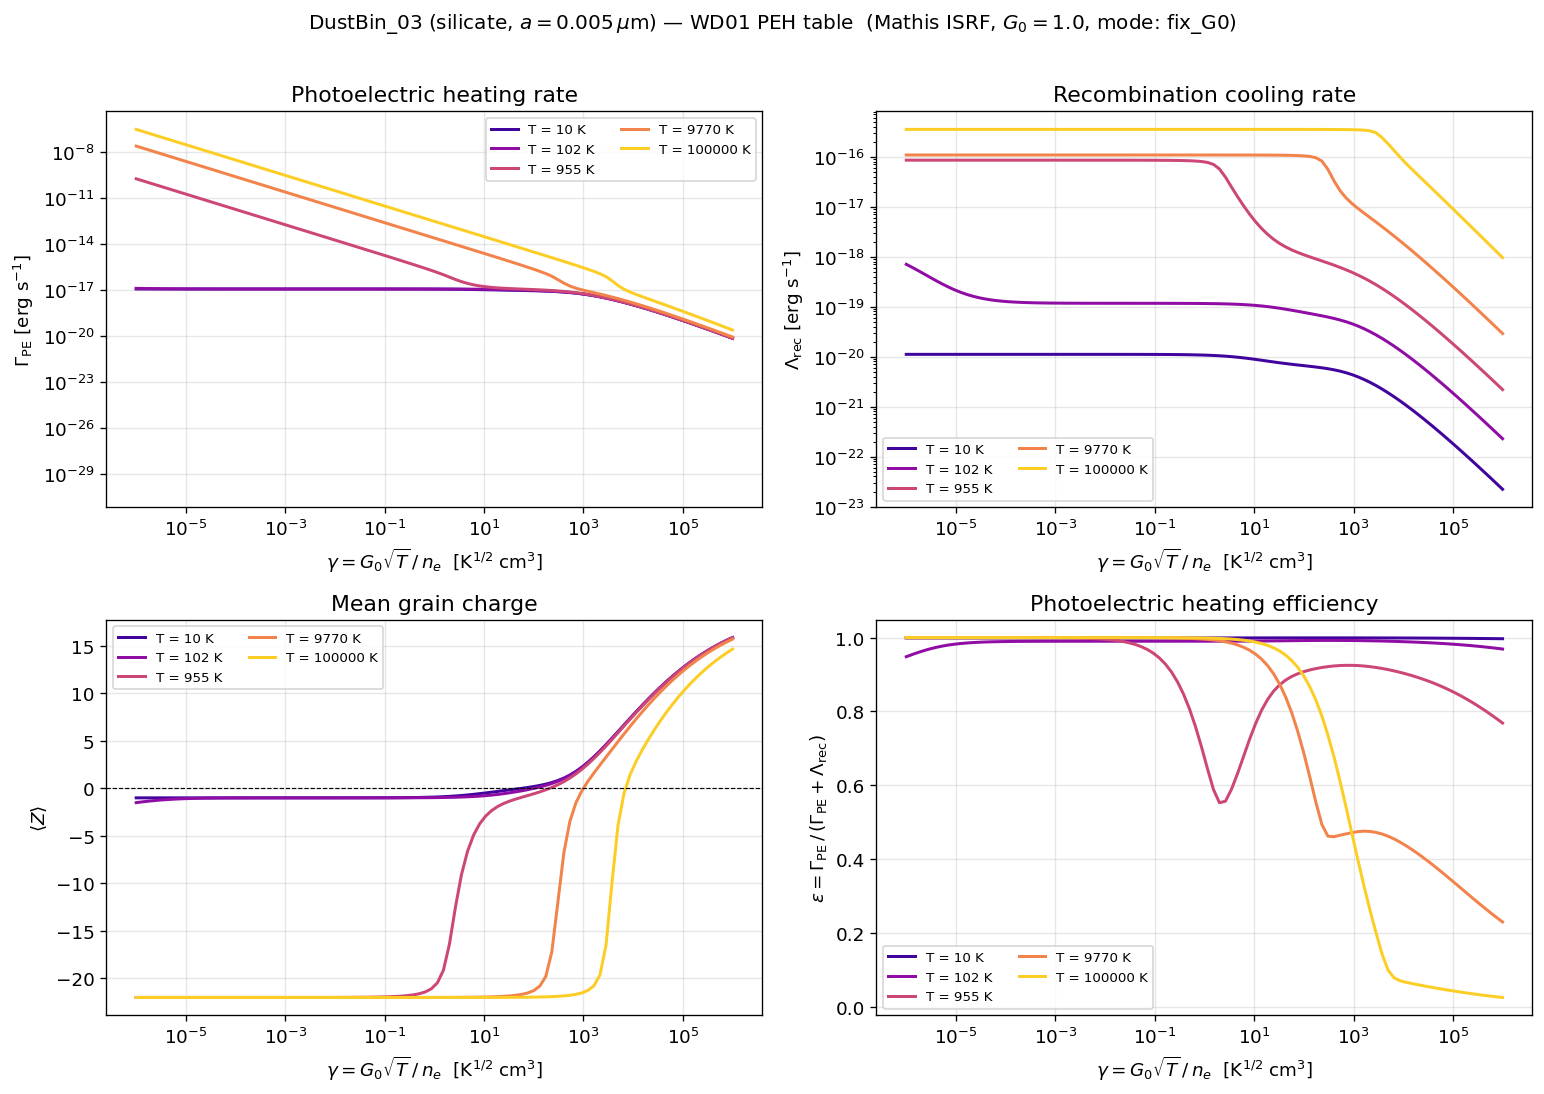

In [16]:
## --- 6e. Dust photoelectric heating — DustBin_03 (silicate 0.005 µm) ---
# Pre-computed PEH/recombination tables (T × γ grid) from heating_DustBin_03.npz
peh_npz_path = REPO / "model_data" / "dust_photoelectric_heating_data" / "heating_DustBin_03.npz"
d_peh = np.load(peh_npz_path, allow_pickle=True)

T_peh_grid    = d_peh["T"]           # shape (100,) K
gamma_peh_grid = d_peh["gamma"]      # shape (100,)
peh_rate      = d_peh["peh_rate"]    # shape (100, 100)  [erg/s],  axes: T × γ
rec_rate      = d_peh["rec_rate"]    # shape (100, 100)  [erg/s]
Zmean_peh     = d_peh["Zmean_grid"]  # shape (100, 100)
mode_peh      = str(d_peh["mode"])
G0_peh        = float(d_peh["fixed_value"])

print(f"Dust PEH table: {str(d_peh['bin_id'])}  "
      f"({str(d_peh['grain_type'])}, a={float(d_peh['grain_size_micron'])} µm)")
print(f"  T grid     : {T_peh_grid.min():.0f} – {T_peh_grid.max():.0f} K  "
      f"({len(T_peh_grid)} points)")
print(f"  γ grid     : {gamma_peh_grid.min():.1e} – {gamma_peh_grid.max():.1e}  "
      f"({len(gamma_peh_grid)} points)")
print(f"  mode       : {mode_peh},  G₀ = {G0_peh}")

# Select representative T slices
T_plot   = [10.0, 100.0, 1000.0, 1e4, 1e5]
cmap_T   = plt.cm.plasma
t_colors = cmap_T(np.linspace(0.1, 0.9, len(T_plot)))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for Ti, c in zip(T_plot, t_colors):
    i_T = np.argmin(np.abs(T_peh_grid - Ti))
    lbl = f"T = {T_peh_grid[i_T]:.0f} K"
    g   = gamma_peh_grid
    peh = peh_rate[i_T, :]
    rec = rec_rate[i_T, :]
    Zm  = Zmean_peh[i_T, :]
    eff = np.where(peh + rec > 0, peh / (peh + rec), np.nan)

    axes[0, 0].loglog(g, np.maximum(peh, 1e-50), color=c, lw=1.8, label=lbl)
    axes[0, 1].loglog(g, np.maximum(rec, 1e-50), color=c, lw=1.8, label=lbl)
    axes[1, 0].semilogx(g, Zm, color=c, lw=1.8, label=lbl)
    axes[1, 1].semilogx(g, np.clip(eff, 0.0, 1.0), color=c, lw=1.8, label=lbl)

axes[0, 0].axhline(1e-30, lw=0)  # force y-axis lower limit
for ax, title, ylabel in [
    (axes[0, 0], "Photoelectric heating rate",
     r"$\Gamma_{\rm PE}$ [erg s$^{-1}$]"),
    (axes[0, 1], "Recombination cooling rate",
     r"$\Lambda_{\rm rec}$ [erg s$^{-1}$]"),
    (axes[1, 0], "Mean grain charge",
     r"$\langle Z \rangle$"),
    (axes[1, 1], "Photoelectric heating efficiency",
     r"$\epsilon = \Gamma_{\rm PE}\,/\,(\Gamma_{\rm PE} + \Lambda_{\rm rec})$"),
]:
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(r"$\gamma = G_0 \sqrt{T}\,/\,n_e$  [K$^{1/2}$ cm$^3$]")
    ax.legend(fontsize=8, ncol=2)

axes[1, 0].axhline(0, color="k", lw=0.7, ls="--")

fig.suptitle(
    fr"DustBin_03 (silicate, $a=0.005\,\mu$m) — WD01 PEH table  "
    fr"(Mathis ISRF, $G_0 = {G0_peh}$, mode: {mode_peh})",
    fontsize=12, y=1.01
)
fig.tight_layout()
plt.show()


---
### 6f. PAH charging and photoelectric heating — PAHbin_01 ($N_C = 54$, coronene)

Pre-computed PAH PEH tables from `model_data/PAH_photoelectric_heating_data/`.  
Two models are compared:
- **Berne et al. (2022)** — photo-detachment and ionisation cross sections from Berne+22  
- **Tielens (2021)** — classical Tielens photo-cross sections

Both use the **Draine** optical model and the **Mathis** ISRF at $G_0 = 1$.  
Each file contains 100 rows: columns are
$\log_{10}(\gamma)$, $\log_{10}(\epsilon)$, $\log_{10}(P_{\rm rad})$,
$f_{-1}$, $f_0$, $f_{+1}$, $f_{+2}$.


PAHbin_01  Nc = 54  (amin Nc = 24, amax Nc = 96)
  γ range : 3.97e-04 – 3.97e+06
  ε range (Berne)  : 1.770e-04 – 1.909e-01
  ε range (Tielens): 8.332e-05 – 1.910e-01


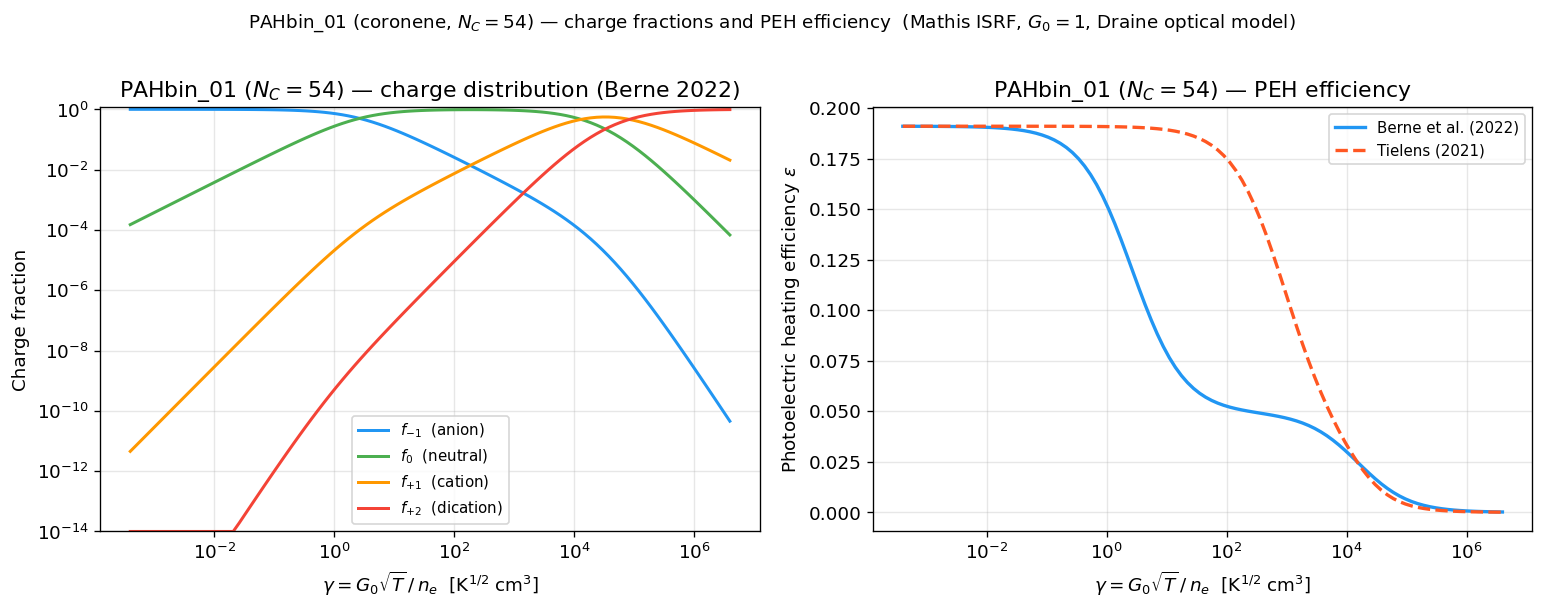

In [17]:
## --- 6f. PAH charging & PEH scan — PAHbin_01 (Nc=54, coronene) ---

def _load_pah_peh_dat(path):
    """Load a PAH PEH .dat table.

    Format
    ------
    Line 0 : column header (ignored)
    Line 1 : number of data rows  N
    Lines 2..N+1 : 7 columns:
        log10(gamma), log10(eff), log10(Prad [erg/s]),
        f_anion, f_neutral, f_1, f_2
    """
    with open(path) as fh:
        lines = [ln.strip() for ln in fh if ln.strip()]
    n_rows = int(lines[1])
    data = np.array(
        [[float(v) for v in ln.split()] for ln in lines[2 : 2 + n_rows]]
    )
    return {
        "log10_gamma": data[:, 0],
        "log10_eff":   data[:, 1],
        "log10_Prad":  data[:, 2],
        "f_anion":     data[:, 3],
        "f_neutral":   data[:, 4],
        "f_1":         data[:, 5],
        "f_2":         data[:, 6],
    }


_pah_dir = REPO / "model_data" / "PAH_photoelectric_heating_data"
berne   = _load_pah_peh_dat(
    _pah_dir / "heating_PAHbin_01_peh_Pinj_ISRF_Mathis_Draine_Berne_0.0005_micron_PAH.dat"
)
tielens = _load_pah_peh_dat(
    _pah_dir / "heating_PAHbin_01_peh_Pinj_ISRF_Mathis_Draine_Tielens_0.0005_micron_PAH.dat"
)

gamma_b  = 10.0 ** berne["log10_gamma"]
gamma_t  = 10.0 ** tielens["log10_gamma"]
eff_b    = 10.0 ** berne["log10_eff"]
eff_t    = 10.0 ** tielens["log10_eff"]

print(f"PAHbin_01  Nc = {pb1_params.nc}  "
      f"(amin Nc = {pb1_params.nc_min}, amax Nc = {pb1_params.nc_max})")
print(f"  γ range : {gamma_b.min():.2e} – {gamma_b.max():.2e}")
print(f"  ε range (Berne)  : {eff_b.min():.3e} – {eff_b.max():.3e}")
print(f"  ε range (Tielens): {eff_t.min():.3e} – {eff_t.max():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: charge fractions vs γ (Berne model) ──────────────────────────
ax = axes[0]
for label, frac, col in [
    (r"$f_{-1}$  (anion)",    berne["f_anion"],   "#2196F3"),
    (r"$f_0$  (neutral)",     berne["f_neutral"], "#4CAF50"),
    (r"$f_{+1}$  (cation)",   berne["f_1"],       "#FF9800"),
    (r"$f_{+2}$  (dication)", berne["f_2"],       "#F44336"),
]:
    ax.loglog(gamma_b, np.maximum(frac, 1e-14), color=col, lw=1.8, label=label)

ax.set_ylim(1e-14, 1.2)
ax.set_xlabel(r"$\gamma = G_0 \sqrt{T}\,/\,n_e$  [K$^{1/2}$ cm$^3$]")
ax.set_ylabel("Charge fraction")
ax.set_title(r"PAHbin_01 ($N_C=54$) — charge distribution (Berne 2022)")
ax.legend(fontsize=9)

# ── Right panel: PEH efficiency vs γ — Berne vs Tielens ──────────────────────
ax = axes[1]
ax.semilogx(gamma_b, eff_b,  color="#2196F3", lw=2.0,
            label="Berne et al. (2022)")
ax.semilogx(gamma_t, eff_t,  color="#FF5722", lw=2.0, ls="--",
            label="Tielens (2021)")

ax.set_xlabel(r"$\gamma = G_0 \sqrt{T}\,/\,n_e$  [K$^{1/2}$ cm$^3$]")
ax.set_ylabel(r"Photoelectric heating efficiency $\epsilon$")
ax.set_title(r"PAHbin_01 ($N_C=54$) — PEH efficiency")
ax.legend(fontsize=9)

fig.suptitle(
    r"PAHbin_01 (coronene, $N_C=54$) — charge fractions and PEH efficiency  "
    r"(Mathis ISRF, $G_0=1$, Draine optical model)",
    fontsize=11, y=1.01
)
fig.tight_layout()
plt.show()


---
## 7. Running Isolated Processes

By enabling only one physics flag at a time we can cleanly isolate each process and see its individual contribution.  
We use the CNM environment (T = 100 K, nH = 100 cm⁻³, G0 = 1) and run for **20 Myr**.


  Accretion only                  converged=True  steps=84
  Sputtering only                 converged=True  steps=31
  Coagulation only                converged=True  steps=31
  Shattering only                 converged=True  steps=31
  PAH photolysis only             converged=True  steps=31
  PAH sputtering only             converged=True  steps=31
  PAH accretion only              converged=True  steps=523
  All dust processes              converged=True  steps=90
  All PAH processes               converged=True  steps=321

All scenarios done.


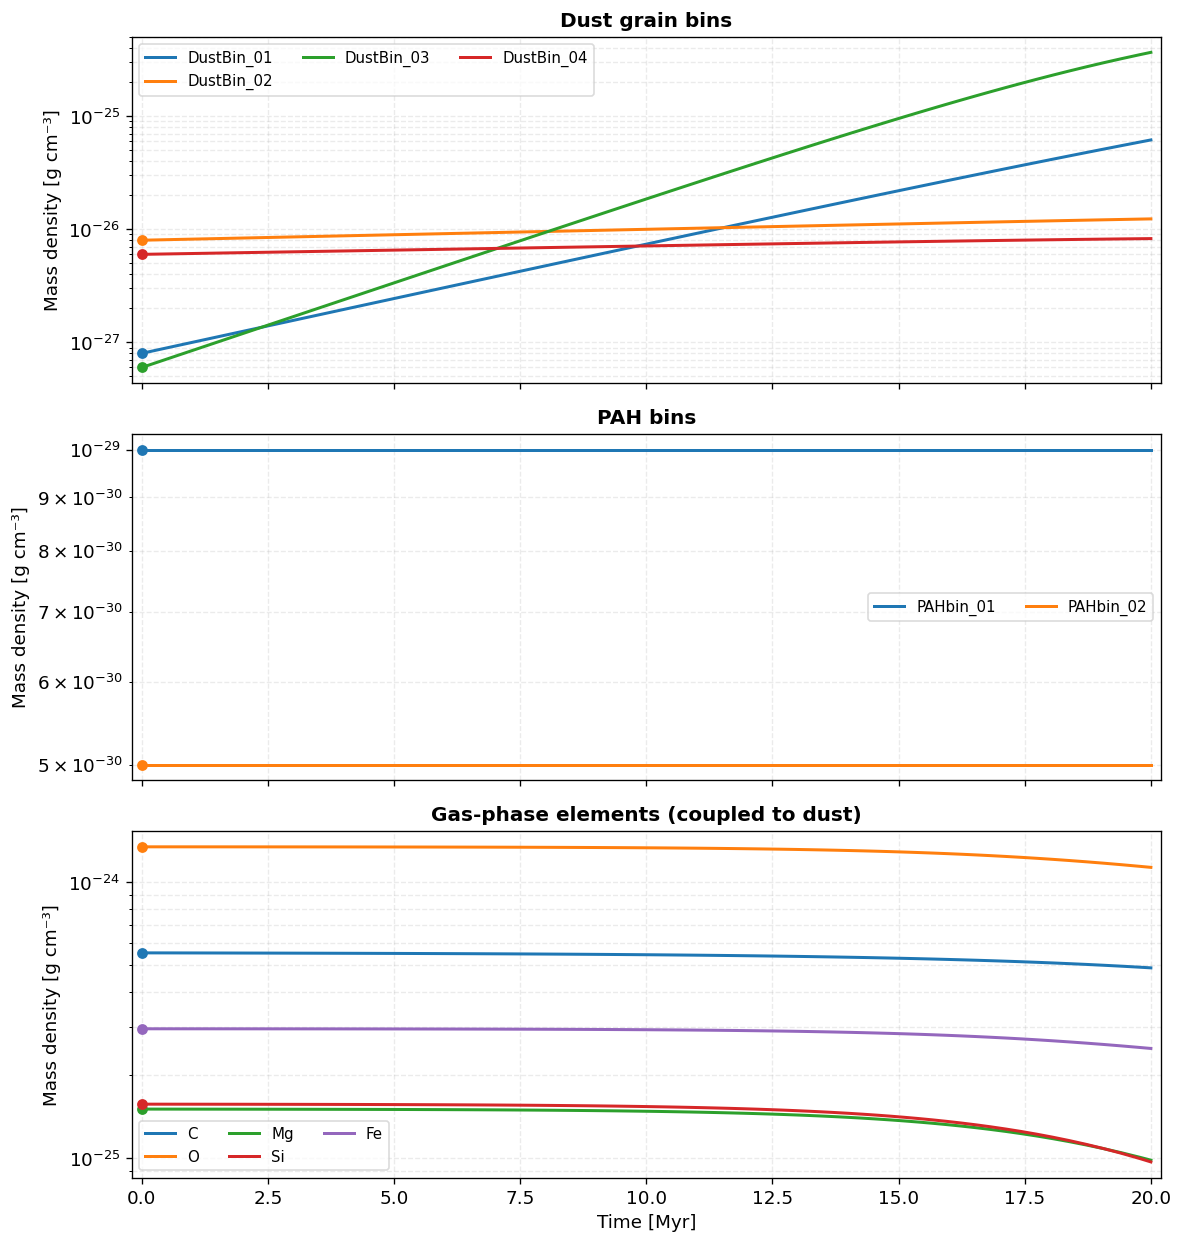

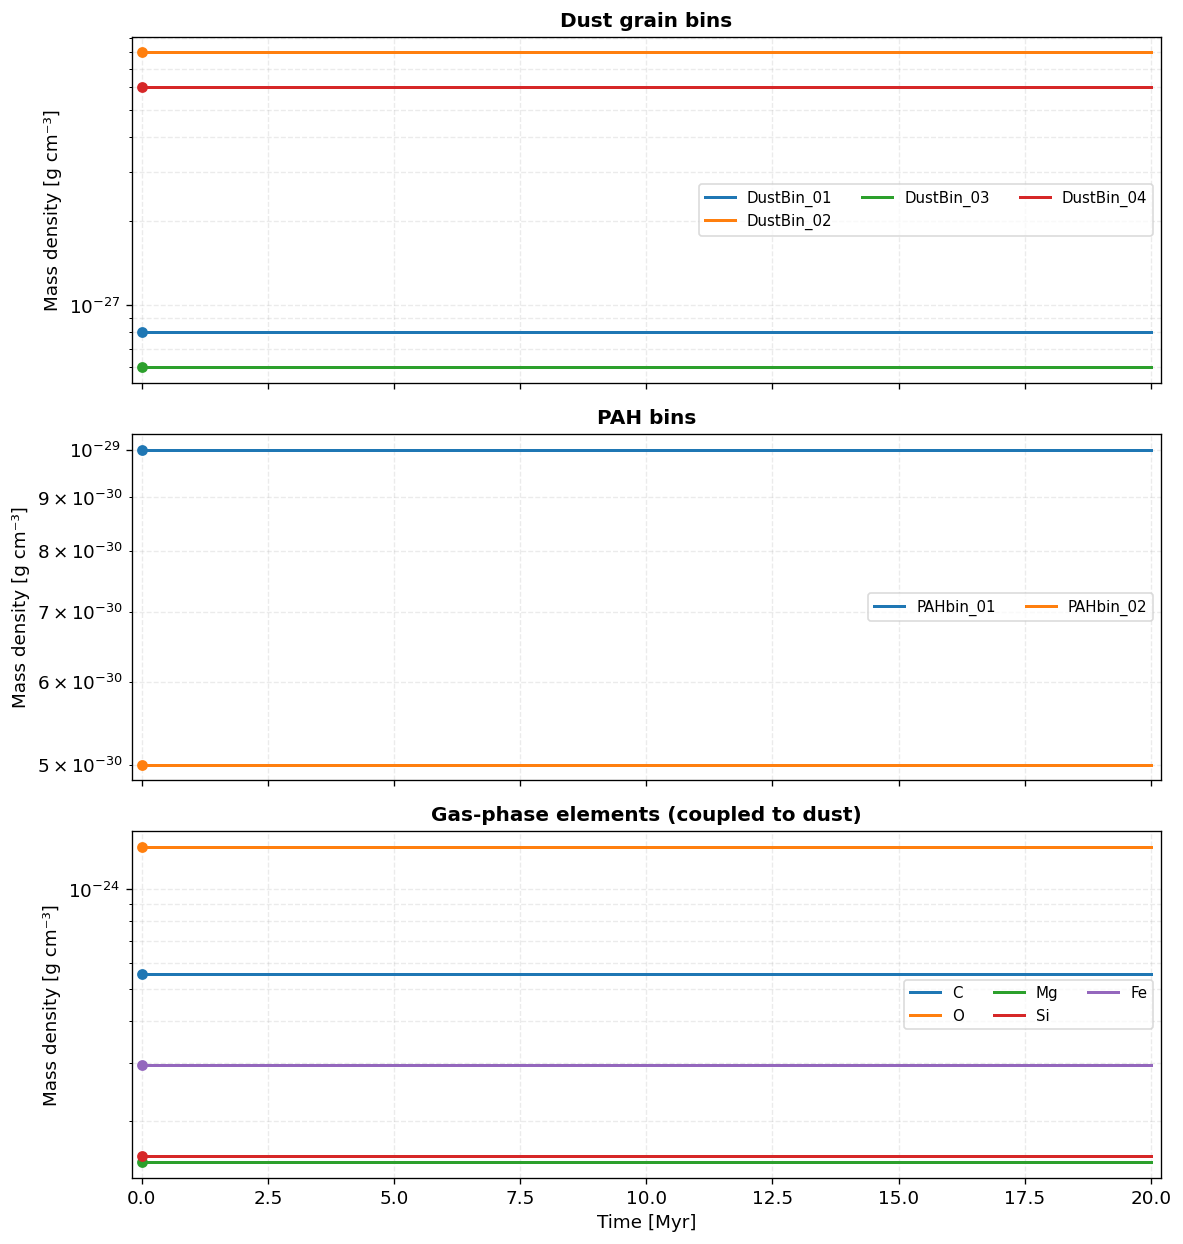

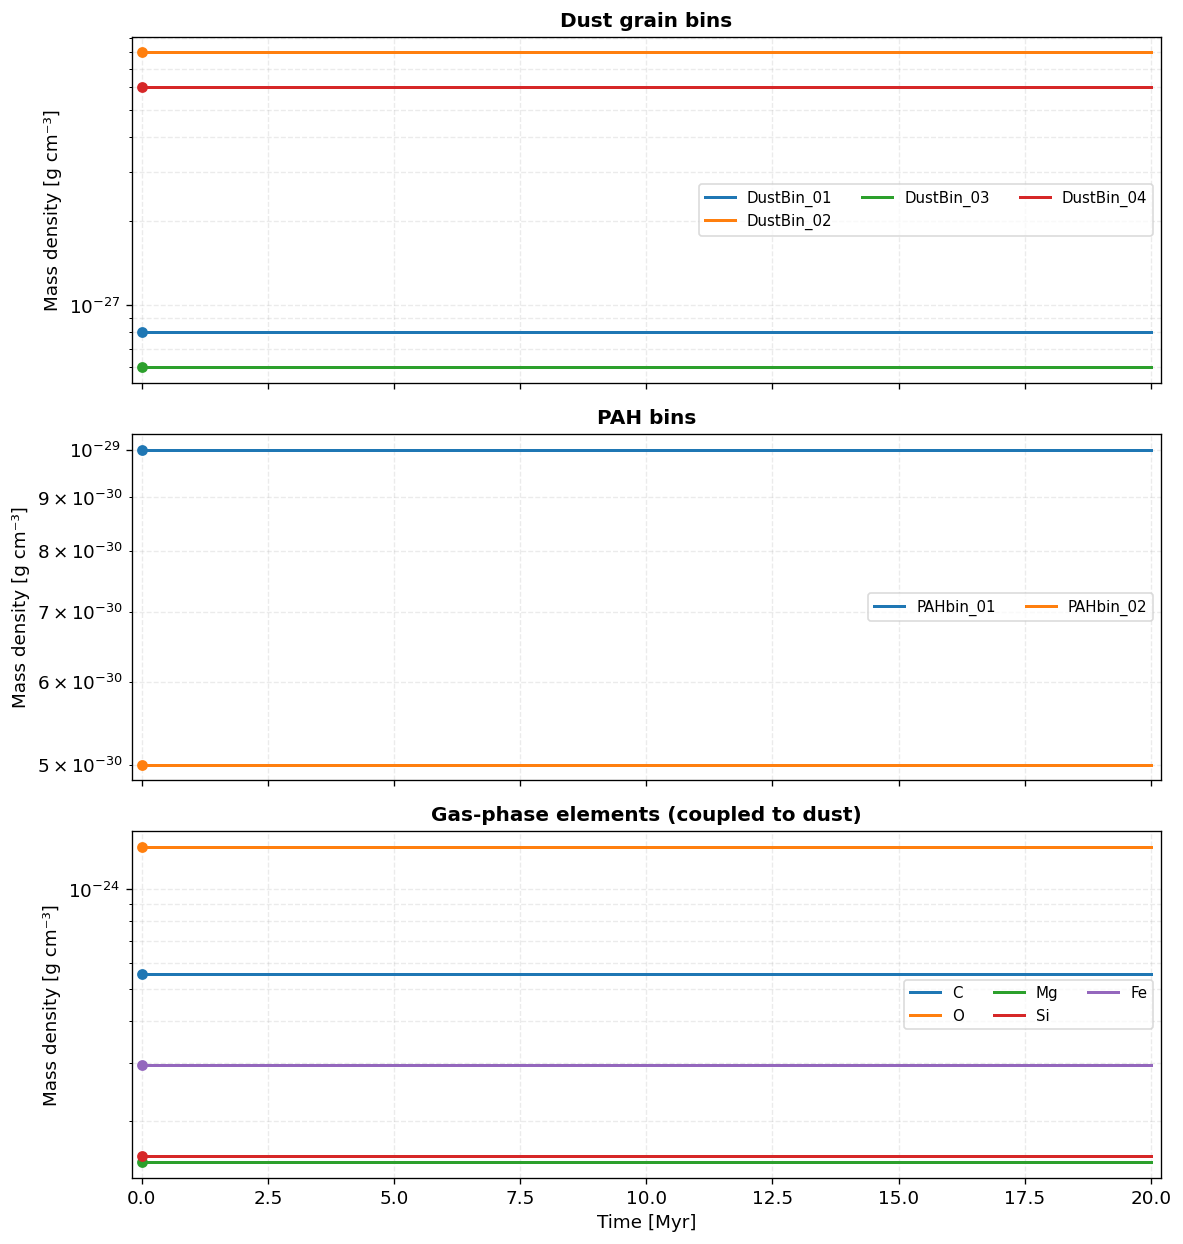

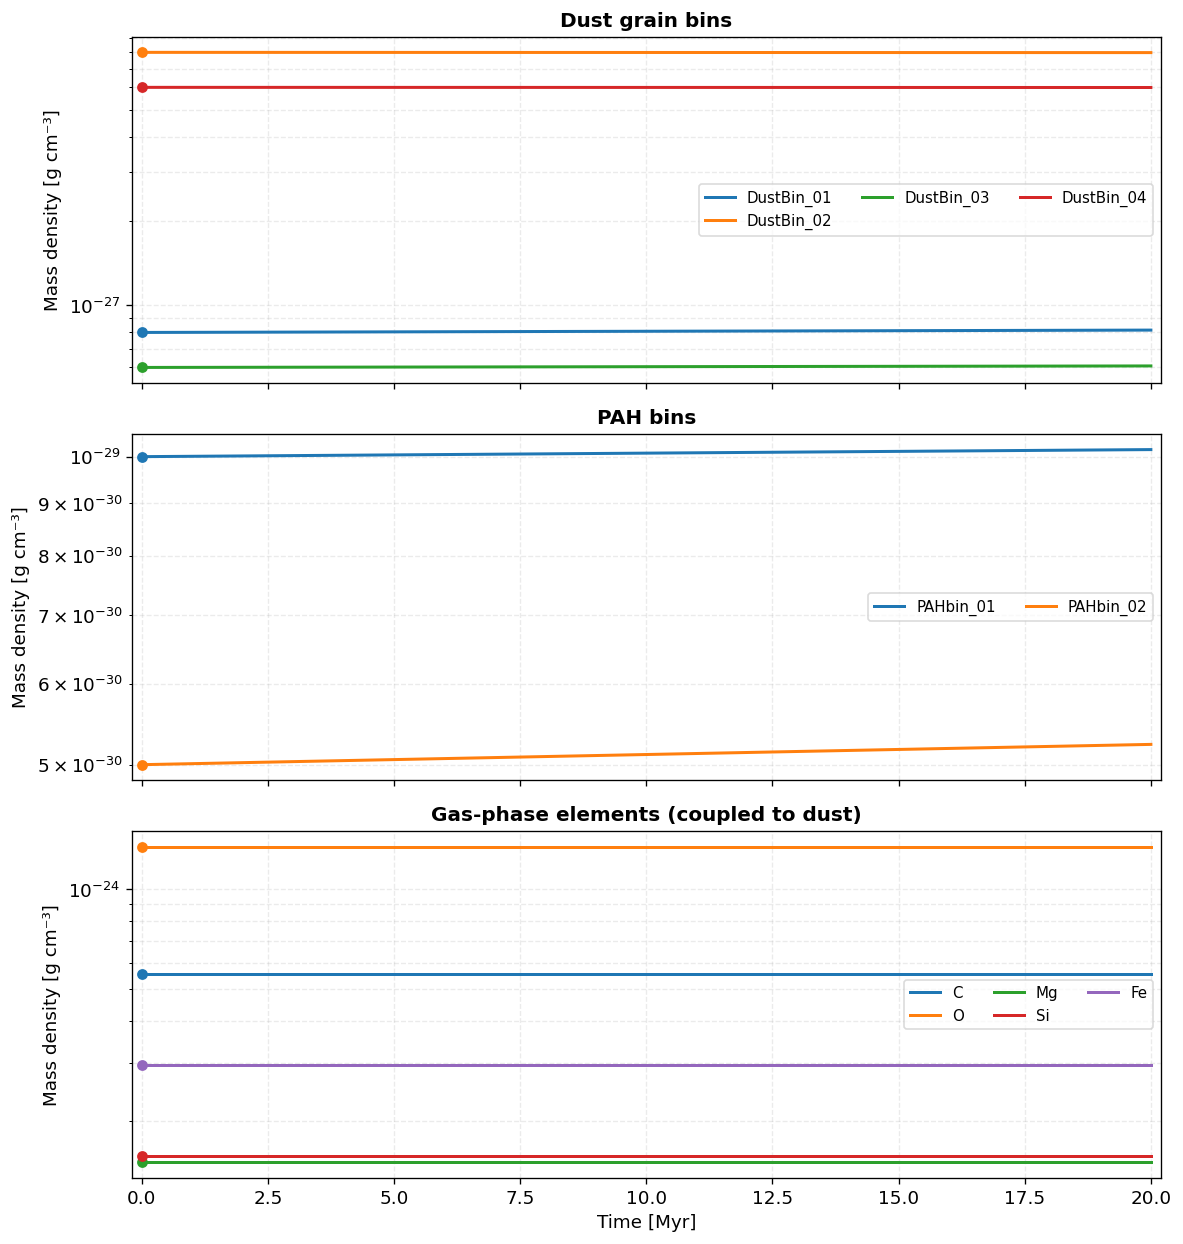

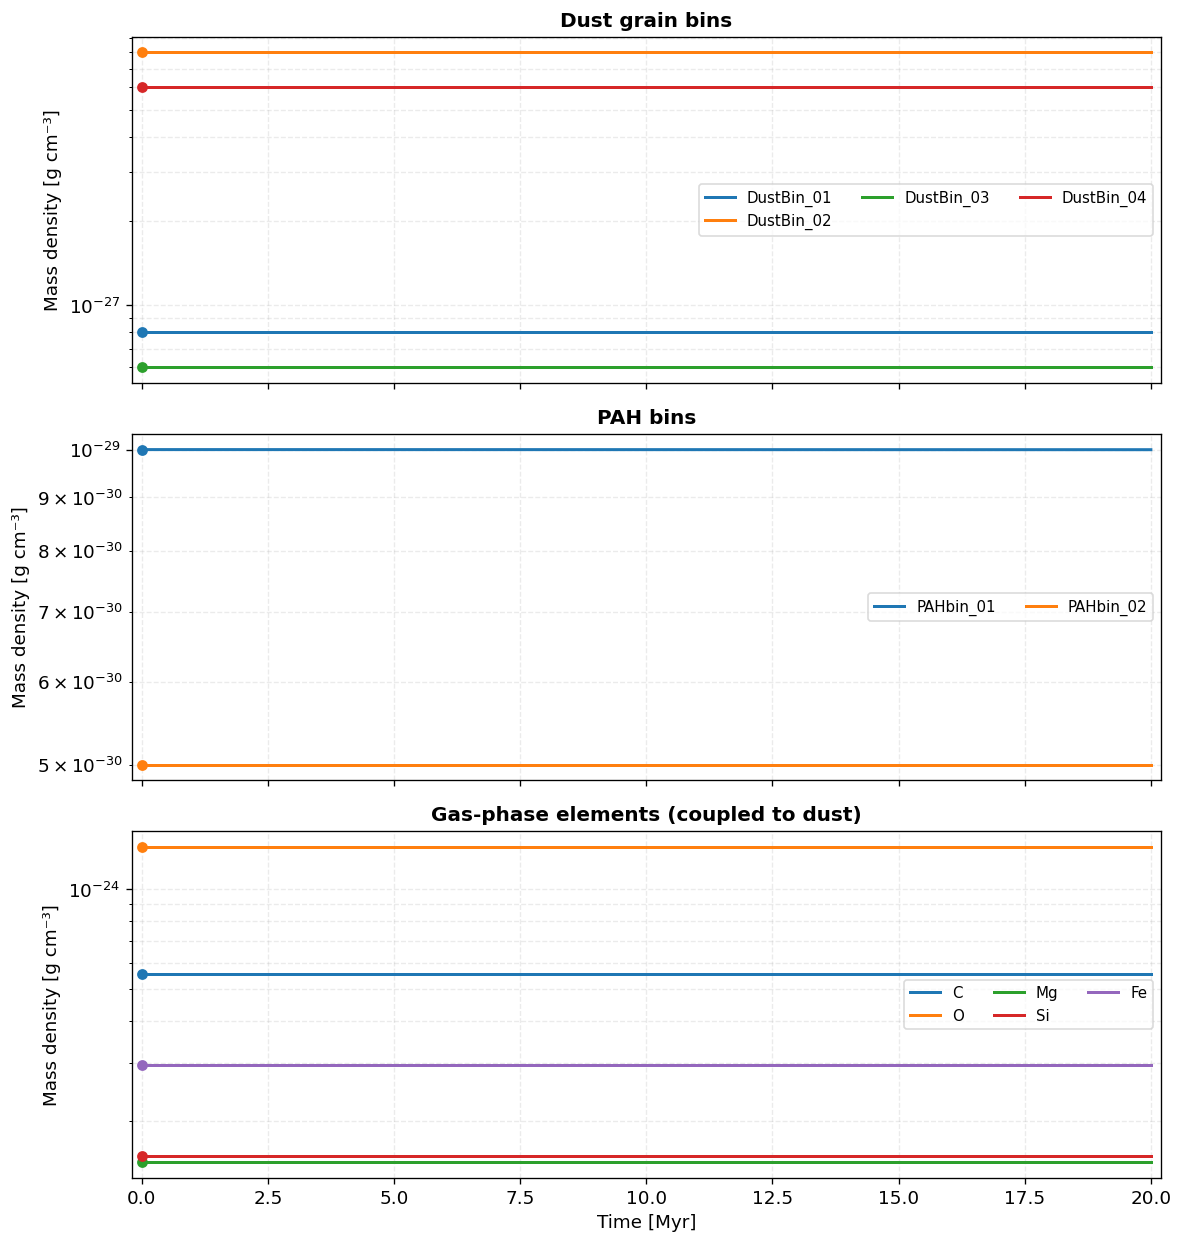

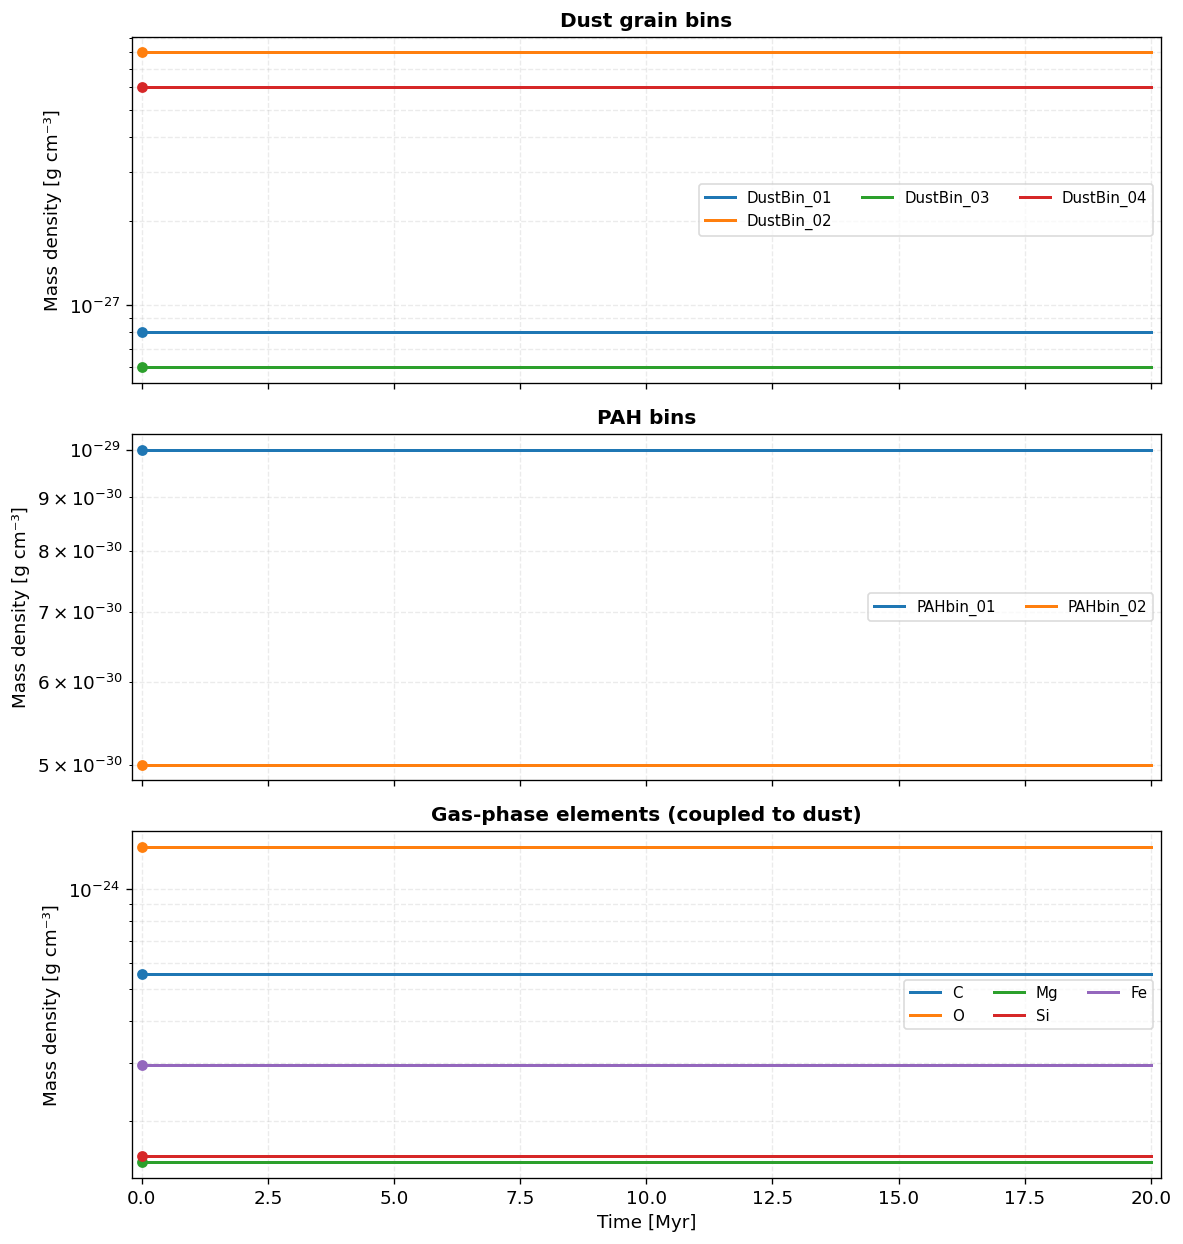

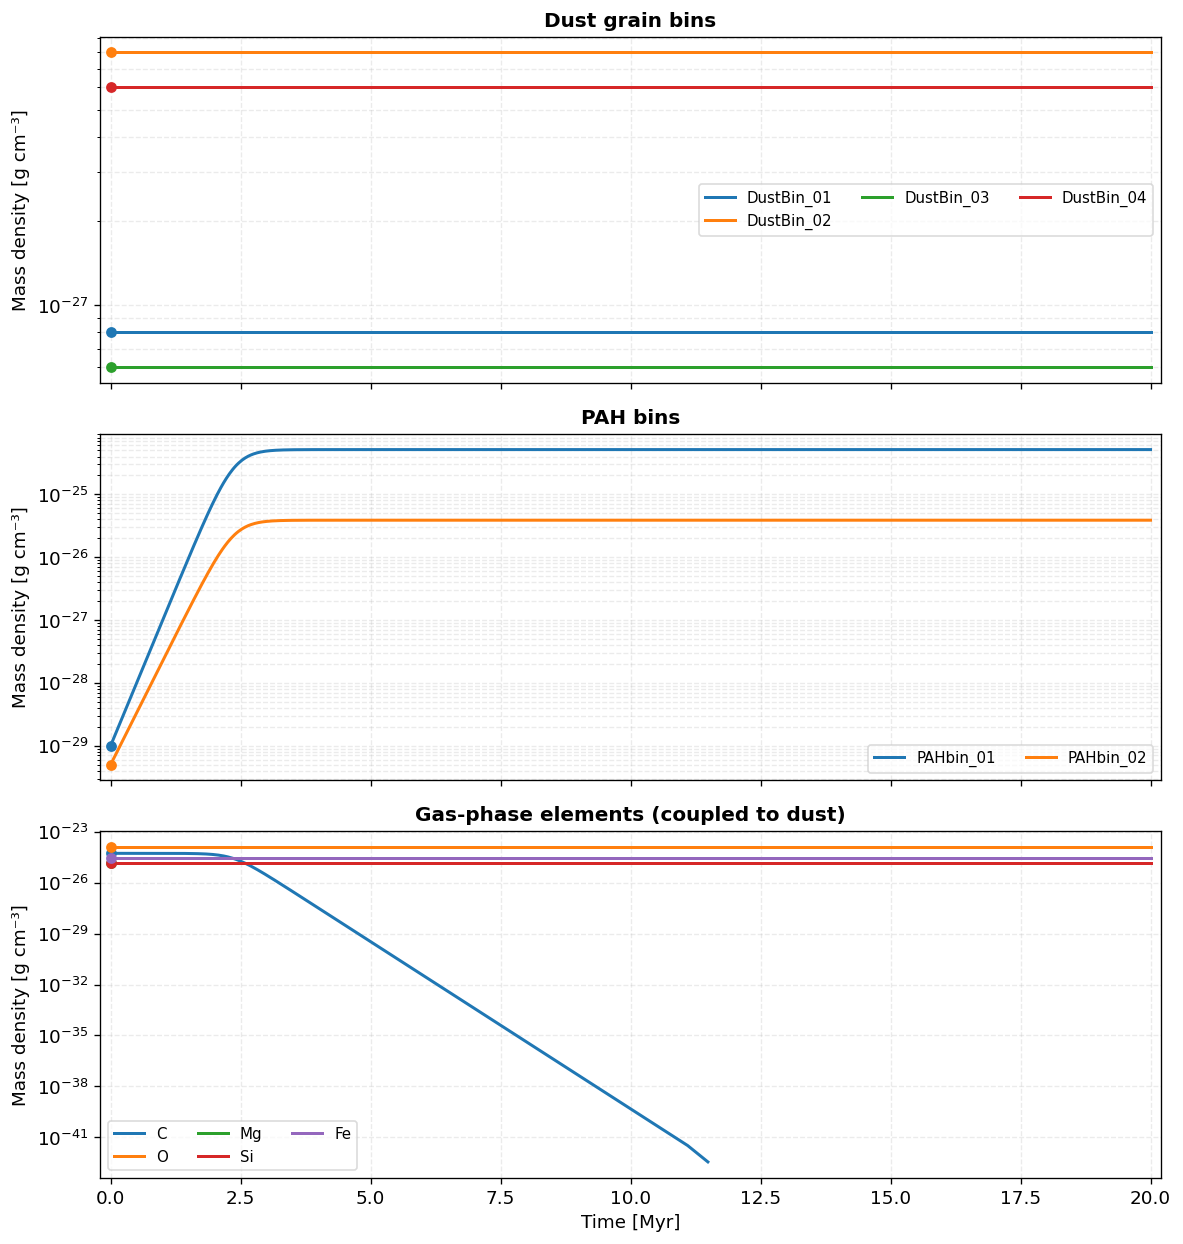

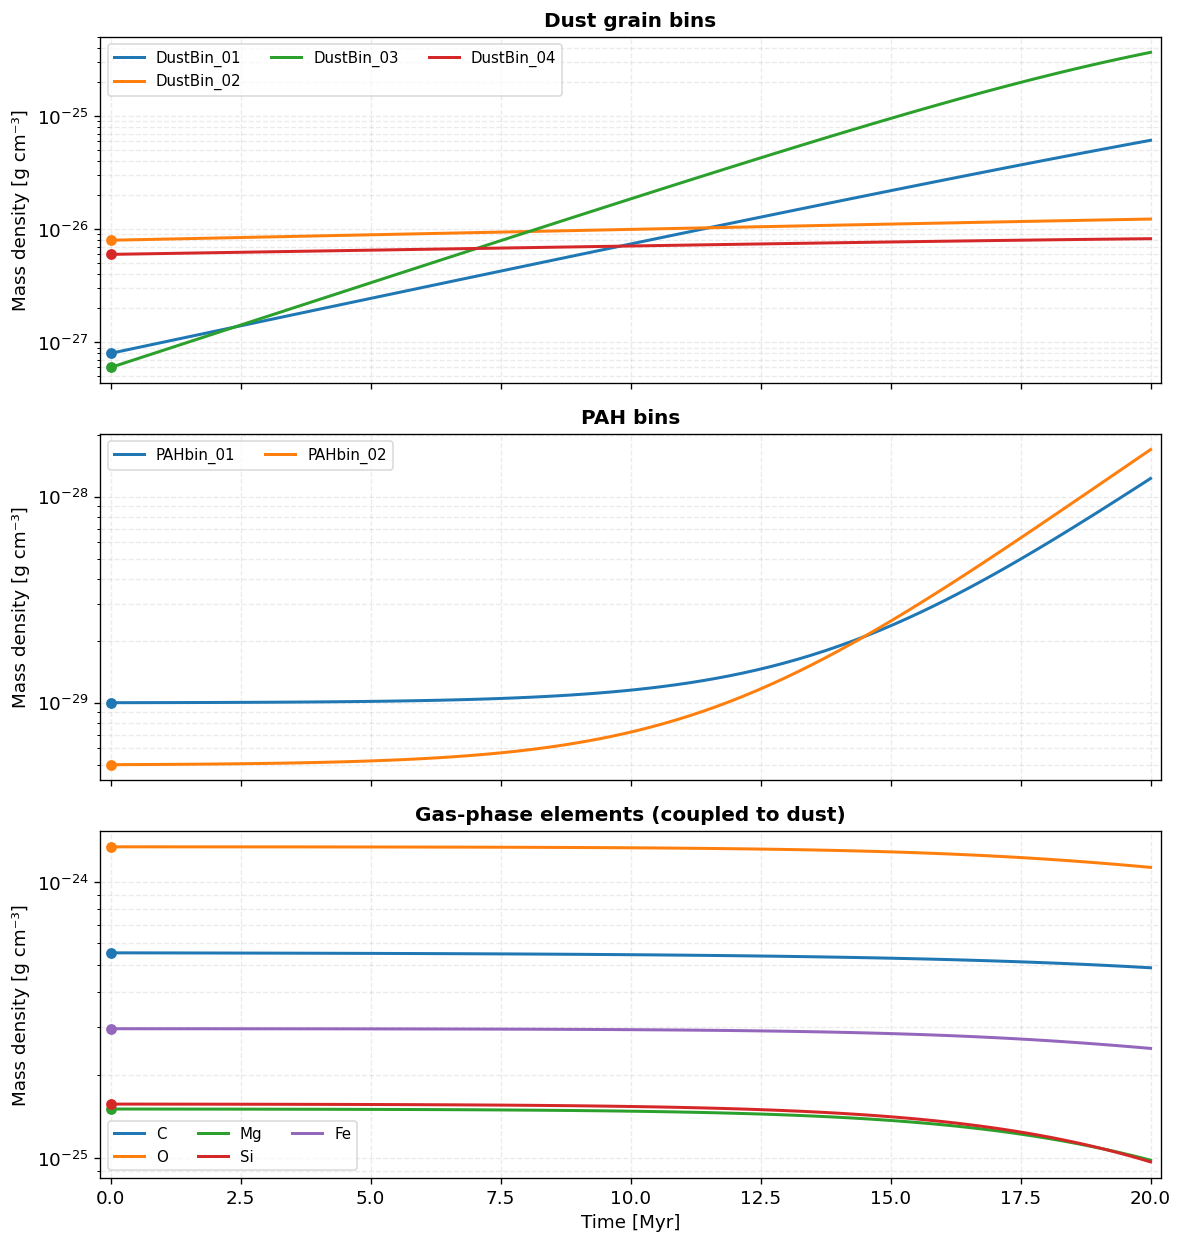

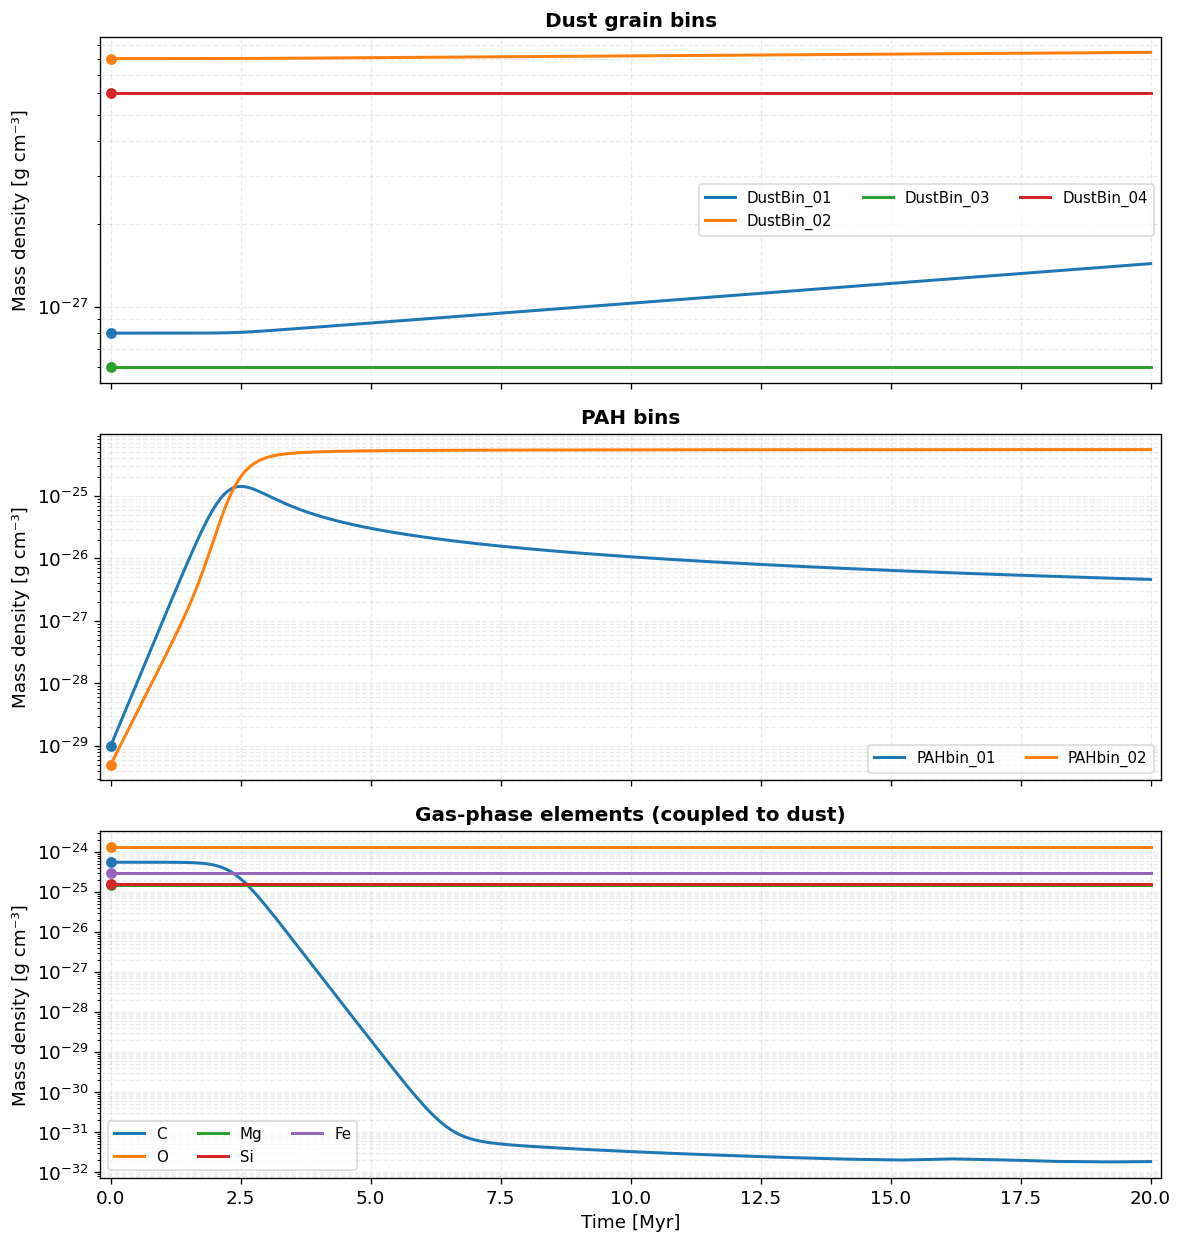

In [14]:
T_END_MYR = 20.0
ENV = {"gas_temperature_K": 100.0, "hydrogen_number_density_cm3": 100.0, "radiation_field_G0": 1.0}

# Dict of scenarios: label -> physics flags to enable
SCENARIOS = {
    "Accretion only":          {"dust_accretion": True},
    "Sputtering only":         {"dust_sputtering": True},
    "Coagulation only":        {"dust_coagulation": True},
    "Shattering only":         {"dust_shattering": True},
    "PAH photolysis only":     {"pah_photolysis": True},
    "PAH sputtering only":     {"pah_sputtering": True},
    "PAH accretion only":      {"pah_accretion": True},
    "All dust processes":      {"dust_accretion": True, "dust_sputtering": True,
                                "dust_coagulation": True, "dust_shattering": True},
    "All PAH processes":       {"pah_accretion": True, "pah_photolysis": True,
                                "pah_sputtering": True, "pah_coalescence": True,
                                "pah_cluster_evaporation": True, "pah_freezing": True},
}

scenario_results = {}

all_off = {k: False for k in BASE_CFG["physics"]}

for label, flags in SCENARIOS.items():
    cfg = copy.deepcopy(BASE_CFG)
    cfg["physics"] = {**all_off, **flags}
    cfg["environment"].update(ENV)
    cfg["solver"]["type"]      = "rk4"
    cfg["solver"]["t_end_Myr"] = T_END_MYR
    cfg["solver"]["countmax"]  = 50000
    tmp = _write_tmp(cfg)
    res = run_chemistry(tmp, verbose=False)
    os.unlink(tmp)
    scenario_results[label] = res
    print(f"  {label:30s}  steps={res['diagnostics']['naccepted']}")

print("\nAll scenarios done.")


In [ ]:
## --- Plot DustBin_03 and PAHbin_01 evolution per scenario ---

_state  = list(scenario_results.values())[0]["state"]
npah    = _state.npah
dust_ids = [db.bin_id for db in _state.dust_bins]
pah_ids  = [pb.bin_id for pb in _state.pah_bins]
i_db3   = next(db.bin_index for db in _state.dust_bins if db.bin_id == "DustBin_03")
i_pb1   = next(pb.bin_index for pb in _state.pah_bins  if pb.bin_id == "PAHbin_01")

n_scenarios = len(SCENARIOS)
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

colors = plt.cm.tab10(np.linspace(0, 1, n_scenarios))

for ax_idx, (bin_label, bin_y_idx, is_pah) in enumerate([
    ("DustBin_03 (small silicate)",  npah + i_db3, False),
    ("PAHbin_01 (monomer, Nc=54)",   i_pb1,         True),
]):
    ax = axes[ax_idx]
    for (label, res), c in zip(scenario_results.items(), colors):
        hist   = res["diagnostics"]["history"]
        t_Myr  = hist["time_s"] / SEC2MYR
        y_dust = hist["y_dust"][:, bin_y_idx]
        ax.semilogy(t_Myr, np.maximum(y_dust, 1e-50), label=label, color=c, lw=1.6)

    ax.set_title(bin_label)
    ax.set_xlabel("Time  [Myr]")
    ax.set_ylabel(r"$\rho$  [g cm$^{-3}$]")
    ax.legend(fontsize=8, ncol=2, loc="best")

fig.suptitle(f"T={ENV['gas_temperature_K']:.0f} K, "
             rf"$n_H={ENV['hydrogen_number_density_cm3']:.0f}$ cm$^{{-3}}$, "
             rf"$G_0={ENV['radiation_field_G0']:.1f}$ — isolated processes", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
## --- Fractional change at t_end per scenario and per bin ---

labels_plot = list(SCENARIOS.keys())
bin_ids_all = pah_ids + dust_ids   # order matching y_dust
n_bins = len(bin_ids_all)
frac_change = np.zeros((n_scenarios, n_bins))

for s_idx, (label, res) in enumerate(scenario_results.items()):
    y0 = res["y_dust_init"]
    yf = res["y_dust_final"]
    for b_idx in range(n_bins):
        if y0[b_idx] > 0:
            frac_change[s_idx, b_idx] = (yf[b_idx] - y0[b_idx]) / y0[b_idx]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(n_bins)
bar_w = 0.85 / n_scenarios

for s_idx, (label, c) in enumerate(zip(labels_plot, colors)):
    ax.bar(x + s_idx * bar_w - 0.85/2 + bar_w/2,
           frac_change[s_idx], bar_w, label=label, color=c, alpha=0.85)

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bin_ids_all, rotation=30, ha="right", fontsize=9)
ax.set_ylabel(r"Fractional change  $(\rho_f - \rho_0)/\rho_0$")
ax.set_title(f"Net fractional change after {T_END_MYR:.0f} Myr — isolated processes")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


---
## 8. Export Functions

CALIMA provides two export functions that write human-readable ASCII files.  
Both can be re-read with `numpy.loadtxt` or `pandas.read_csv`.

### `save_chemistry_txt` — ODE time-series output

Writes a rich self-describing file with:
- A `#`-commented header: initial conditions, active processes, bin parameters, solver diagnostics
- A column-name row: `time_s  time_Myr  h_s  error  <dust bins>  <PAH bins>  <gas elements>`
- One row per accepted ODE step

### `save_equilibrium_txt` — equilibrium solver output

Writes the steady-state result with:
- Initial vs equilibrium density for every dust/PAH bin and gas-phase element
- Fractional change per bin, solver residual, mass conservation check


In [ ]:
## --- 8a. Save the "all dust processes" scenario to a TXT file ---

all_dust_res = scenario_results["All dust processes"]
txt_path = REPO / "all_dust_processes_20Myr.txt"

save_chemistry_txt(all_dust_res, txt_path, config_path=CFG_PATH)
print(f"Saved -> {txt_path.name}  ({txt_path.stat().st_size // 1024} KB)")

# Print the first 35 lines (header + first data rows)
with txt_path.open() as fh:
    for i, line in enumerate(fh):
        print(line, end="")
        if i >= 34:
            break


In [ ]:
## --- 8b. Read the TXT file back with numpy and pandas ---

import numpy as np
import pandas as pd

# numpy: skip comment lines that start with '#'
data_np = np.loadtxt(txt_path, comments="#")
print(f"numpy array shape: {data_np.shape}  (n_steps x n_columns)")

# pandas: read_csv, comment='#', whitespace-separated, no header
# Recover column names from the last commented line
col_names = None
with txt_path.open() as fh:
    for line in fh:
        if line.startswith("#") and "time_s" in line:
            col_names = line.lstrip("# ").split()
            break

if col_names:
    df = pd.read_csv(txt_path, comment="#", sep=r"\s+", header=None, names=col_names)
    print(f"\npandas DataFrame shape: {df.shape}")
    print(df[["time_Myr", "DustBin_03", "PAHbin_01"]].head(8).to_string(index=False))


In [ ]:
## --- 8c. Save the equilibrium result ---

EQ_CFG = REPO / "solvers" / "configs" / "equilibrium_postshock_test.json"
eq_res  = run_chemistry(EQ_CFG, verbose=False)

eq_txt_path = REPO / "equilibrium_postshock.txt"
save_equilibrium_txt(eq_res, eq_txt_path, config_path=EQ_CFG)
print(f"Saved -> {eq_txt_path.name}  ({eq_txt_path.stat().st_size} bytes)")

# Print the full file (it is short)
with eq_txt_path.open() as fh:
    print(fh.read())


---
## 9. Visualising the Results

This final section pulls together the data loaded from the exported files and produces publication-quality plots.


In [ ]:
## --- 9a. Use plot_chemistry_evolution on the "All dust processes" scenario ---
fig = plot_chemistry_evolution(all_dust_res, show=False, time_unit="Myr", logy=True)
fig.suptitle("All dust processes — CNM (T=100 K, nH=100, G0=1), 20 Myr", y=1.01)
plt.show()


In [ ]:
## --- 9b. Read data from the exported TXT and re-plot from file ---
# This demonstrates the complete file -> plot workflow without any solver objects

df = pd.read_csv(txt_path, comment="#", sep=r"\s+", header=None, names=col_names)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

dust_cols = [c for c in col_names if c.startswith("DustBin")]
pah_cols  = [c for c in col_names if c.startswith("PAHbin")]
el_cols   = [c for c in col_names if c not in ("time_s","time_Myr","h_s","error")
             and not c.startswith("Dust") and not c.startswith("PAH")]

# Panel (0,0): all dust bins
ax = axes[0, 0]
for col in dust_cols:
    ax.semilogy(df["time_Myr"], df[col].clip(lower=1e-50), label=col, lw=1.6)
ax.set_title("Dust grain bins")
ax.set_ylabel(r"$\rho_{\rm dust}$  [g cm$^{-3}$]")
ax.legend(fontsize=9)

# Panel (0,1): all PAH bins
ax = axes[0, 1]
for col in pah_cols:
    ax.semilogy(df["time_Myr"], df[col].clip(lower=1e-50), label=col, lw=1.6)
ax.set_title("PAH bins")
ax.set_ylabel(r"$\rho_{\rm PAH}$  [g cm$^{-3}$]")
ax.legend(fontsize=9)

# Panel (1,0): gas-phase element evolution
ax = axes[1, 0]
metal_cols = [c for c in el_cols if c not in ("H", "He")]
for col in metal_cols:
    ax.semilogy(df["time_Myr"], df[col].clip(lower=1e-50), label=col, lw=1.6)
ax.set_title("Gas-phase metals (non-H/He)")
ax.set_xlabel("Time  [Myr]")
ax.set_ylabel(r"$\rho_{\rm gas}$  [g cm$^{-3}$]")
ax.legend(fontsize=9, ncol=2)

# Panel (1,1): adaptive step size and error
ax = axes[1, 1]
ax.semilogy(df["time_Myr"], df["h_s"].clip(lower=1e-10) / SEC2MYR,
            color="steelblue", lw=1.4, label="step size [Myr]")
ax2 = ax.twinx()
ax2.semilogy(df["time_Myr"], df["error"].clip(lower=1e-20),
             color="tomato", lw=1.2, alpha=0.7, label="error")
ax.set_title("RK4 step size and error")
ax.set_xlabel("Time  [Myr]")
ax.set_ylabel("Step size  [Myr]", color="steelblue")
ax2.set_ylabel("Max rel. error", color="tomato")
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=9)

fig.suptitle("Read from TXT export — all dust processes, 20 Myr", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
## --- 9c. All PAH processes run + export ---

cfg_all_pah = copy.deepcopy(BASE_CFG)
cfg_all_pah["physics"] = {
    **{k: False for k in BASE_CFG["physics"] if "dust" in k},
    "pah_accretion":           True,
    "pah_photolysis":          True,
    "pah_sputtering":          True,
    "pah_coalescence":         True,
    "pah_cluster_evaporation": True,
    "pah_freezing":            True,
}
cfg_all_pah["environment"].update(ENV)
cfg_all_pah["solver"]["type"]      = "rk4"
cfg_all_pah["solver"]["t_end_Myr"] = T_END_MYR
cfg_all_pah["solver"]["countmax"]  = 50000

tmp_pah = _write_tmp(cfg_all_pah)
pah_res = run_chemistry(tmp_pah, verbose=True)
os.unlink(tmp_pah)

txt_pah = REPO / "all_pah_processes_20Myr.txt"
save_chemistry_txt(pah_res, txt_pah, config_path=CFG_PATH)
print(f"\nSaved -> {txt_pah.name}")

fig = plot_chemistry_evolution(pah_res, show=False, time_unit="Myr", logy=True)
fig.suptitle("All PAH processes — CNM, 20 Myr", y=1.01)
plt.show()


In [ ]:
## --- 9d. Mass conservation check across all scenarios ---

el_h = _state.el_names.index("H")

print(f"{'Scenario':35s}  {'H init':>12}  {'H final':>12}  {'max dM/M0 (%)':>13}")
print("-" * 78)
for label, res in scenario_results.items():
    mc      = res["mass_conservation"]
    max_err = float(mc["max_el_err"]) * 100.0   # already a float
    h_init  = res["y_gas_init"][el_h]
    h_final = res["y_gas_final"][el_h]
    print(f"{label:35s}  {h_init:>12.4e}  {h_final:>12.4e}  {max_err:>13.2e}")
